Catherine Carmosino

01/12/2025

This code follows the steps taken in [Gene set enrichment and pathway analysis](https://www.sc-best-practices.org/conditions/gsea_pathway.html)

# Loading in the Data

In [1]:
#the package imports we need for single-cell enrichment analysis using decoupler
import hisepy
import numpy as np
import scanpy as sc
import anndata as ad
import decoupler as dc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


In [2]:
#importing the data file
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [3]:
#creating a list
adata_list = []

#looping through the file names
for h5ad_file in h5ad_files:
    #read the file into an AnnData object using scanpy
    adata = sc.read_h5ad(h5ad_file)
    #appending the AnnData file into the list
    adata_list.append(adata)

In [4]:
#concatenating/combining all of the AnnData objects into one
adata = sc.concat(adata_list)

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [5]:
adata

AnnData object with n_obs × n_vars = 450000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    obsm: 'X_pca', 'X_umap'

In [6]:
#looking at the observations in adata
adata.obs

,original_barcodes,batch_id,pool_id,chip_id,well_id,n_umis,n_genes,plate_location,cyto_treatment,drug_treatment,...,drug_mw,drug_solvent,drug_pathway,drug_target,drug_description,drug_chembl_name,drug_chembl_id,AIFI_L1,AIFI_L2,leiden_2
barcodes,,,,,,,,,,,,,,,,,,,,,
c83df837-3e10-4e8a-9329-68b7fc9a4cc7,ACCGCCATCAACCGCTACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W1,1827.0,490,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,19
445c57f1-bc42-40cb-a2c3-859baf98794c,TCCCGCAAGTAATGGCACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W1,989.0,370,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD8 Naive,8
6a5bc577-b17e-492d-af15-6ae76aff2c4f,ATGGGTTAGGGTTGCAACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W2,1976.0,532,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,6
293648fb-97f6-4937-9594-91eeb7fdf58d,CCCGTAGTCTGGAAACACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W2,846.0,370,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,3
33df20df-bf79-43ab-a9b4-02c9c97c89ad,ACACTAAAGTGTGCAGACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W3,1299.0,422,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2f3f3b7e-c7d8-4318-a014-92388b889c4e,GATGGACGTAACTAGGTGGATCTGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W4,1291.0,408,D5,IL-6,A4138,...,312.37,DMSO,Chromatin/Epigenetics,JAK,Janus kinase inhibitor,TOFACITINIB,CHEMBL221959,T cell,CD4 Central Memory,10
90977027-a8bb-4d08-83de-bdb16264d4af,TGAATCTTCACGTTATTGGATCTGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W1,881.0,360,D5,IL-6,A4138,...,312.37,DMSO,Chromatin/Epigenetics,JAK,Janus kinase inhibitor,TOFACITINIB,CHEMBL221959,T cell,CD4 Central Memory,5
ac0541a6-aefa-4d36-8c7e-97d80ef707e8,CTATGGGAGTGCCCTGTGGATCTGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W3,1243.0,374,D5,IL-6,A4138,...,312.37,DMSO,Chromatin/Epigenetics,JAK,Janus kinase inhibitor,TOFACITINIB,CHEMBL221959,T cell,CD8 Naive,3


In [7]:
# combine multiple anndata objects and adds a "sample" column telling you which dataset each cell came from; aka, which DRUG NAME each cell was treated with!
adata = ad.concat(adata_list, label="sample")

# make sure all observations are unique
adata.obs_names_make_unique()

# filtering out CD8aa because there aren't enough samples
adata = adata[adata.obs.AIFI_L2 != "CD8aa"]

#normalizing
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [8]:
import re

unique_drug_names = adata.obs['drug_name'].unique()

def clean_name(name):
    name = re.sub(' \\(.*\\) ', ' ', name)
    name = re.sub(' \\(.*\\)$', '', name)
    name = name.replace("IL6 Control", "IL-6 Control")
    return name

# for name in unique_drug_names:
#     print(clean_name(name))

adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)

In [10]:
# pick the exact labels as they appear in your obs
priority = ["IL-6 Control", "DMSO Control"]  # e.g., use "IL-6", "DMSO" if that's the exact text

# ensure categorical dtype
adata.obs["clean_drug_name"] = (
    adata.obs["clean_drug_name"].astype("category")
)

# current categories
cats = list(adata.obs["clean_drug_name"].cat.categories)

# move priority labels to the front (keep the rest in their original order)
others = [c for c in cats if c not in priority]
new_order = priority + others

# apply the new order
adata.obs["clean_drug_name"] = (
    adata.obs["clean_drug_name"].cat.reorder_categories(new_order, ordered=True)
)


In [19]:
# Make a dictionary to match drug names to colors
drug_color_dict = {
    'IL-6 Control': '#51d4c7',
    'DMSO Control': '#818689',
    'Afatinib': '#135669',
    'Afatinib dimaleate': '#3a728d',
    'Baricitinib': '#b35100',
    'Baricitinib phosphate': '#fb6f00',
    'Canertinib': '#d593c7',
    'Canertinib dihydrochloride': '#fcb0ef',
    'Erlotinib': '#208bbd',
    'Erlotinib Hydrochloride': '#bad5e3',
    'Gefitinib': '#7030a0',
    'Gefitinib hydrochloride': '#9382d4',
    'NVP-BSK805': '#d4c300',
    'NVP-BSK805 2HCl': '#fadf80',
    'Ruxolitinib': '#008f00',
    'Ruxolitinib phosphate': '#92d051',
    'Tofacitinib': '#c90000',
    'Tofacitinib Citrate': '#fd7a69'
}

# Make sure the type is categorical for the column we want to color by
adata.obs['clean_drug_name'] = adata.obs['clean_drug_name'].astype('category')

# Make a list of colors that matches the order of categories
color_list = [drug_color_dict[drug_name] for drug_name in adata.obs['clean_drug_name'].cat.categories]

# Add the list to uns['<column_name>_colors']
adata.uns['clean_drug_name_colors'] = color_list

In [21]:
#storing the counts for later use
adata.layers["counts"] = adata.X.copy()
adata.layers["log_transformed"] = np.log1p(adata.X)

In [22]:
adata

AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'log_transformed'

In [23]:
#the current adata object comes with UMAP and PCA embeddings but these have been corrected for stimulation condition
#don’t want these corrected values for this analysis, so recompute these
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [24]:
sc.tl.rank_genes_groups(
        adata = adata,
        groupby = "clean_drug_name",
        reference = "DMSO Control",
        method = "wilcoxon",
        key_added = "wilcoxon",
        layer = "log_transformed"
    )

... storing 'drug_cas_number' as categorical
... storing 'drug_description' as categorical
... storing 'drug_chembl_name' as categorical
... storing 'drug_chembl_id' as categorical


In [25]:
adata

AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_transformed'
    obsp: 'distances', 'connectivities'

# Enrichment analysis

## Pathway Scoring with Progeny

Discriptions of the Different pathways:

- **Androgen**: involved in the growth and development of the male reproductive organs
- **EGFR**: regulates growth, survival, migration, apoptosis, proliferation, and differentiation in mammalian cells
- **Estrogen**: promotes the growth and development of the female reproductive organs
- **Hypoxia**: promotes angiogenesis and metabolic reprogramming when O2 levels are low
- **JAK-STAT**: involved in immunity, cell division, cell death, and tumor formation
- **MAPK**: integrates external signals and promotes cell growth and proliferation
- **NFkB**: regulates immune response, cytokine production and cell survival
- **p53**: regulates cell cycle, apoptosis, DNA repair and tumor suppression
- **PI3K**: promotes growth and proliferation
- **TGFb**: involved in development, homeostasis, and repair of most tissues
- **TNFa**: mediates haematopoiesis, immune surveillance, tumour regression and protection from infection
- **Trail**: induces apoptosis
- **VEGF**: mediates angiogenesis, vascular permeability, and cell migration
- **WNT**: regulates organ morphogenesis during development and tissue repair

In [26]:
#accessing progeny
#a comprehensive resource that provides a collection of pathways and their target genes
#and weights for each interaction
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


In [27]:
progeny_pathways = ["JAK-STAT", "Androgen", "EGFR", "Estrogen", "Hypoxia", "MAPK", 
            "NFkB", "p53", "PI3K", "TGFb", "TNFa", "Trail", "VEGF", "WNT"] 

In [28]:
#computing pathway scores for the entire adata object
dc.mt.ulm(data=adata, net=progeny)
adata

AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'
    varm: 'PCs'
    layers: 'counts', 'log_transformed'
    obsp: 'distances', 'connectivities'

In [29]:
#extract scores for the entire adata object
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 449975 × 14
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'

In [30]:
#making empty distionary 
cell_type_results = {}

#looping through the cell types in the adata object column
for cell_type in adata.obs['AIFI_L2'].unique():    
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()

    #getting the enrichment score
    score = dc.pp.get_obsm(cell_type_subset, key="score_ulm")

    #running rankby group against the DMSO Control
    df = dc.tl.rankby_group(
        adata=score, 
        groupby="clean_drug_name", 
        reference="DMSO Control", 
        method="wilcoxon"
    )

    #adding the cell type name to a data frame (adding a column)
    df['cell_type'] = cell_type

    #adding the rest of the stats to the dataframe
    cell_type_results[cell_type] = df

#concatinating all of the results
all_results_progeny = pd.concat(cell_type_results)

In [31]:
all_results_progeny

group     reference      name       stat  \
CD4 Central Memory 0       Afatinib  DMSO Control  JAK-STAT  37.930362   
                   1       Afatinib  DMSO Control      NFkB  27.766313   
                   2       Afatinib  DMSO Control      TNFa  24.221749   
                   3       Afatinib  DMSO Control      EGFR  20.991255   
                   4       Afatinib  DMSO Control      PI3K  17.025555   
...                             ...           ...       ...        ...   
Treg               233  Tofacitinib  DMSO Control      TGFb   1.047506   
                   234  Tofacitinib  DMSO Control  Androgen  -0.800176   
                   235  Tofacitinib  DMSO Control     Trail   0.748601   
                   236  Tofacitinib  DMSO Control       p53  -0.146967   
                   237  Tofacitinib  DMSO Control      NFkB   0.131942   

                        meanchange           pval           padj  \
CD4 Central Memory 0      0.716463   0.000000e+00   0.000000e+00   
                   1      0.516447  1.107264e-169  7.750851e-169   
                   2      0.385409  1.312830e-129  6.126538e-129   
                   3      0.388839   7.883595e-98   2.759258e-97   
                   4      0.276219   5.308669e-65   1.486427e-64   
...                            ...            ...            ...   
Treg               233    0.028022   2.948661e-01   4.128126e-01   
                   234   -0.019307   4.236087e-01   5.297805e-01   
                   235    0.011406   4.540976e-01   5.297805e-01   
                   236   -0.005338   8.831583e-01   8.950300e-01   
                   237   -0.002038   8.950300e-01   8.950300e-01   

                                 cell_type  
CD4 Central Memory 0    CD4 Central Memory  
                   1    CD4 Central Memory  
                   2    CD4 Central Memory  
                   3    CD4 Central Memory  
                   4    CD4 Central Memory  
...                                    ...  
Treg               233                Treg  
                   234                Treg  
                   235                Treg  
                   236                Treg  
                   237                Treg  

[1904 rows x 8 columns]

### Heatmap

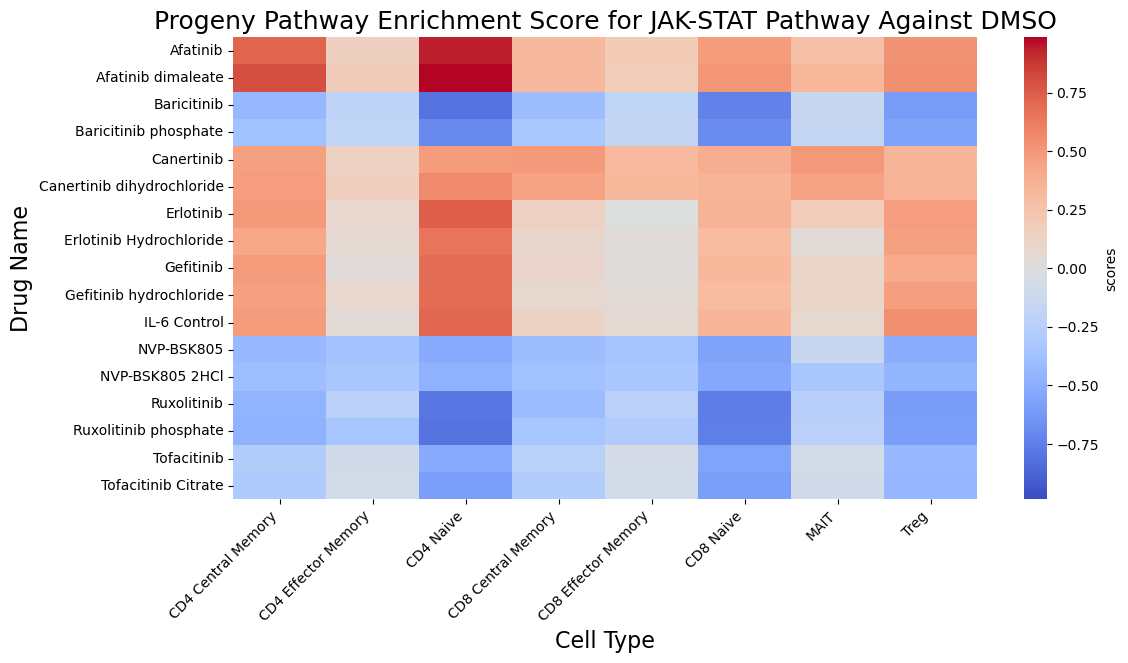

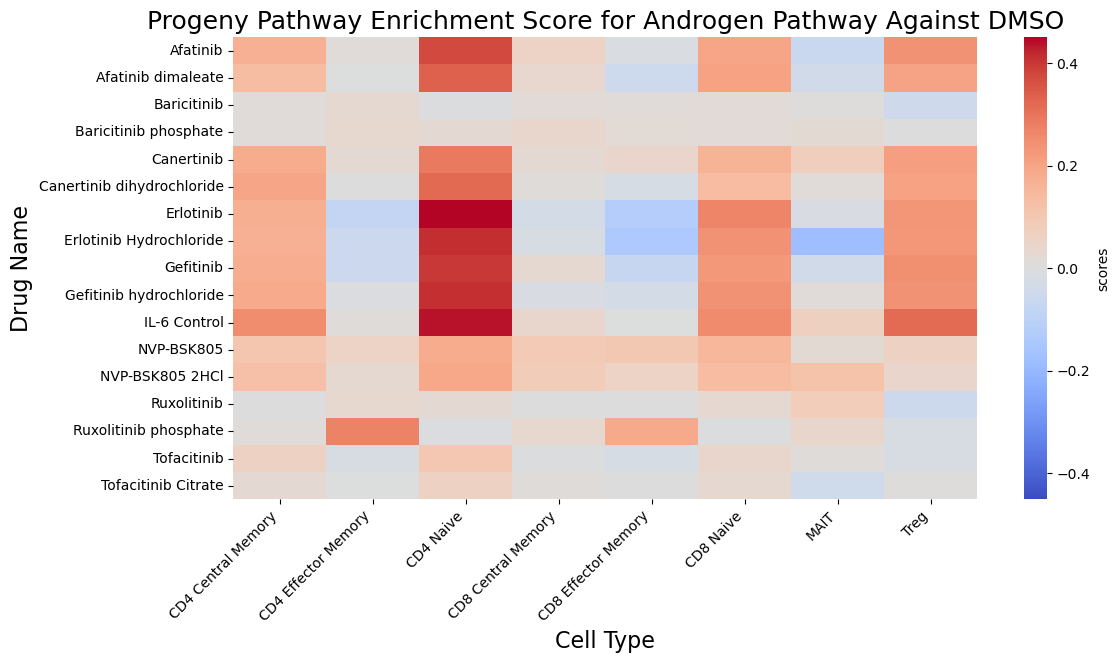

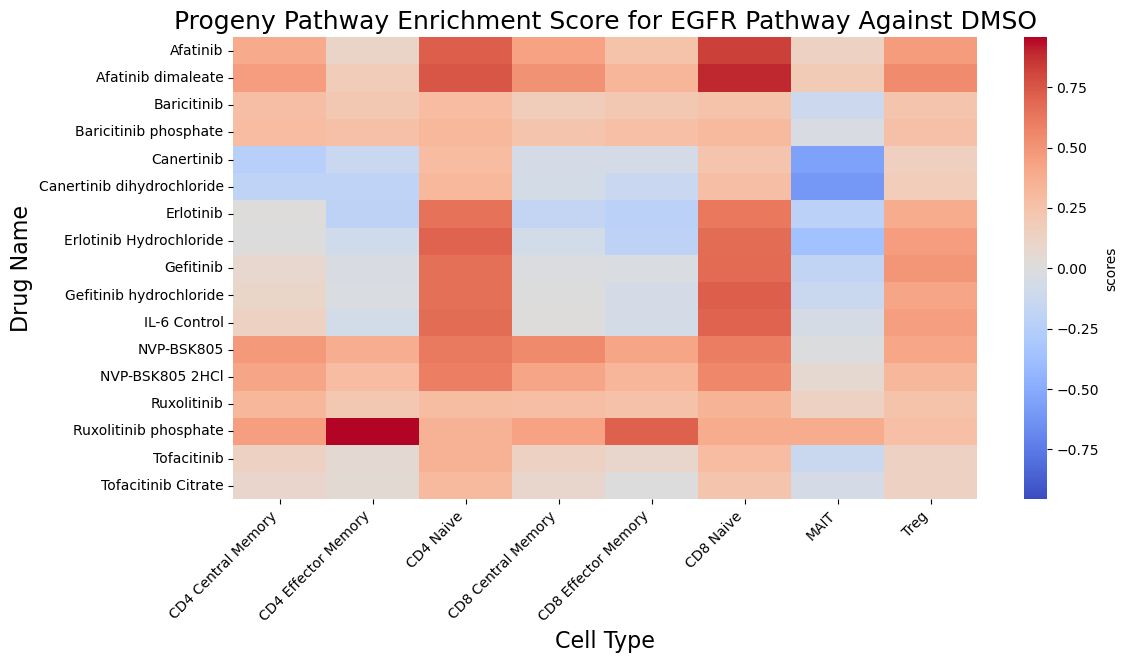

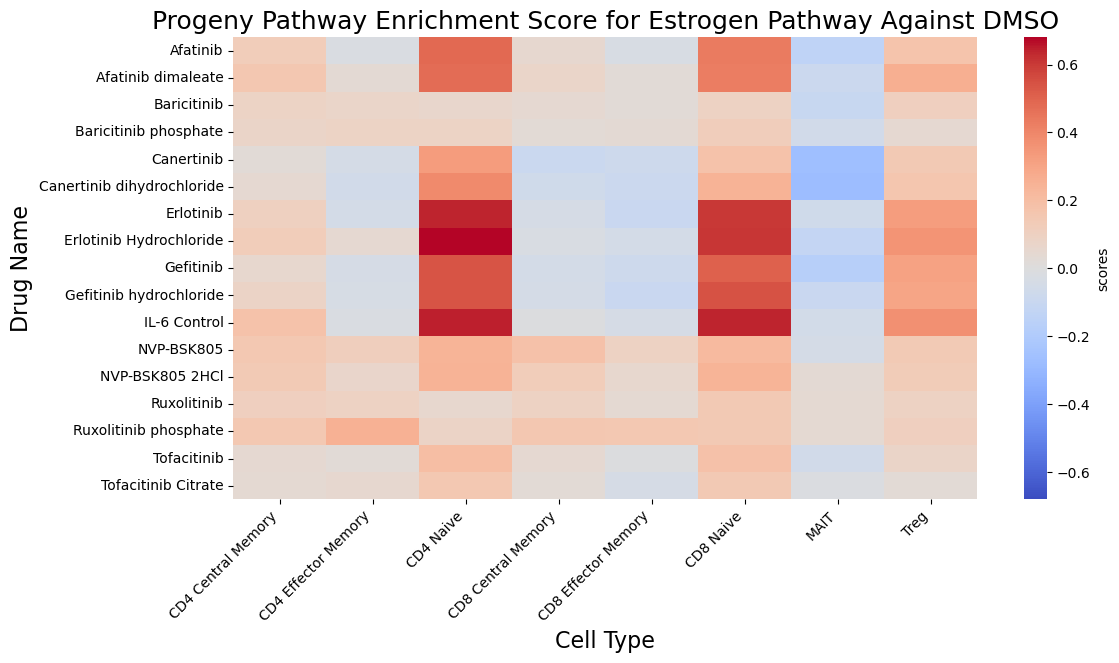

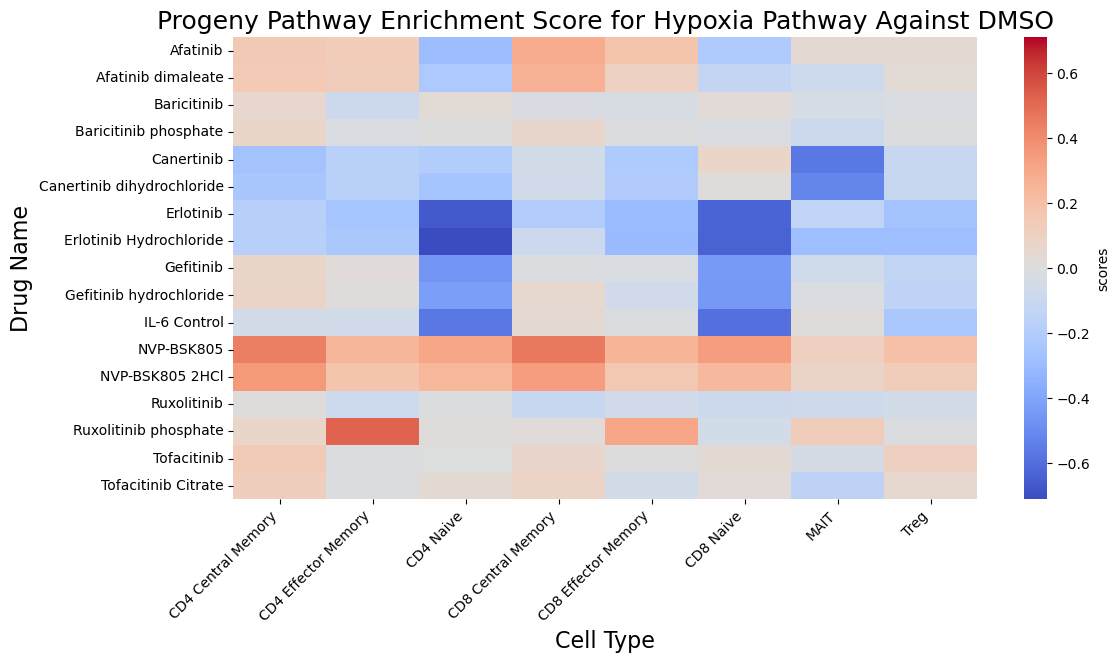

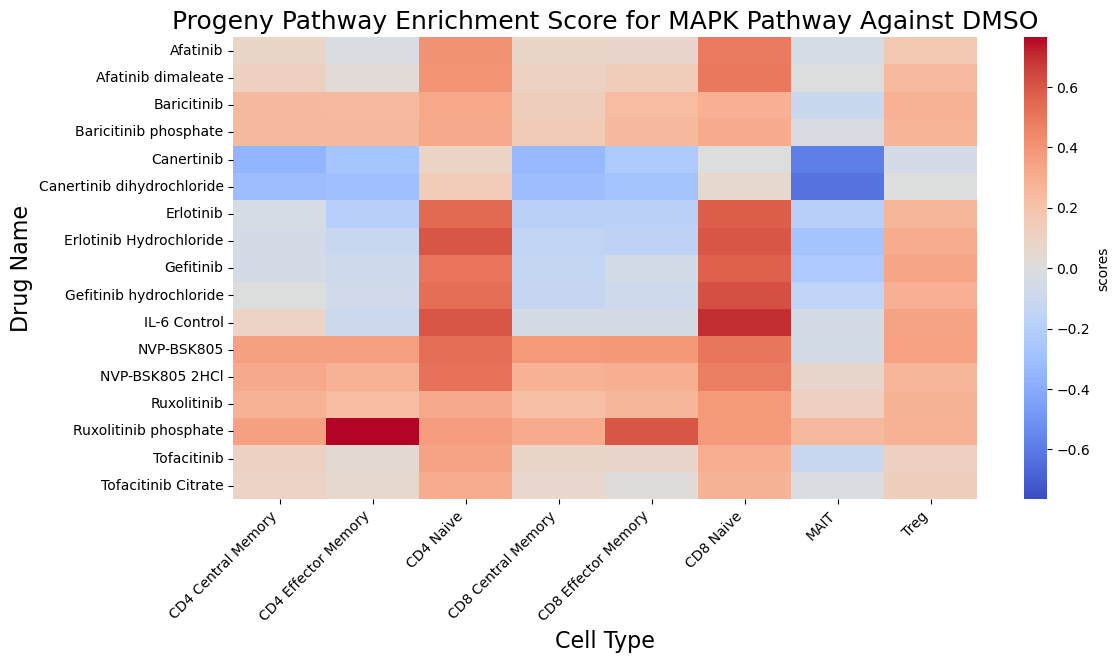

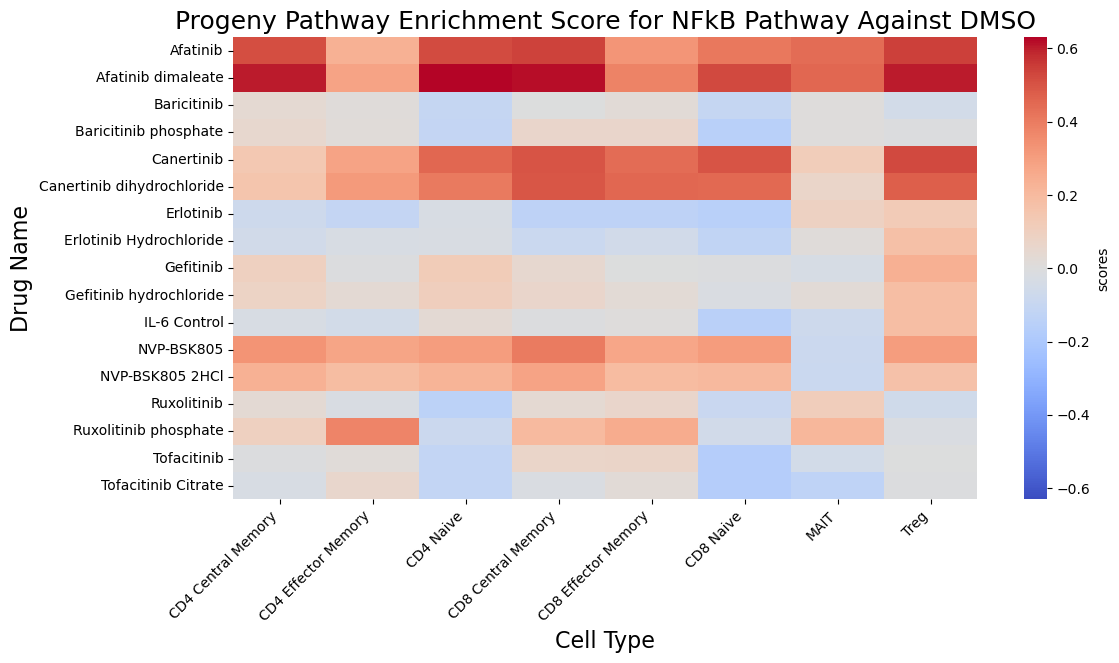

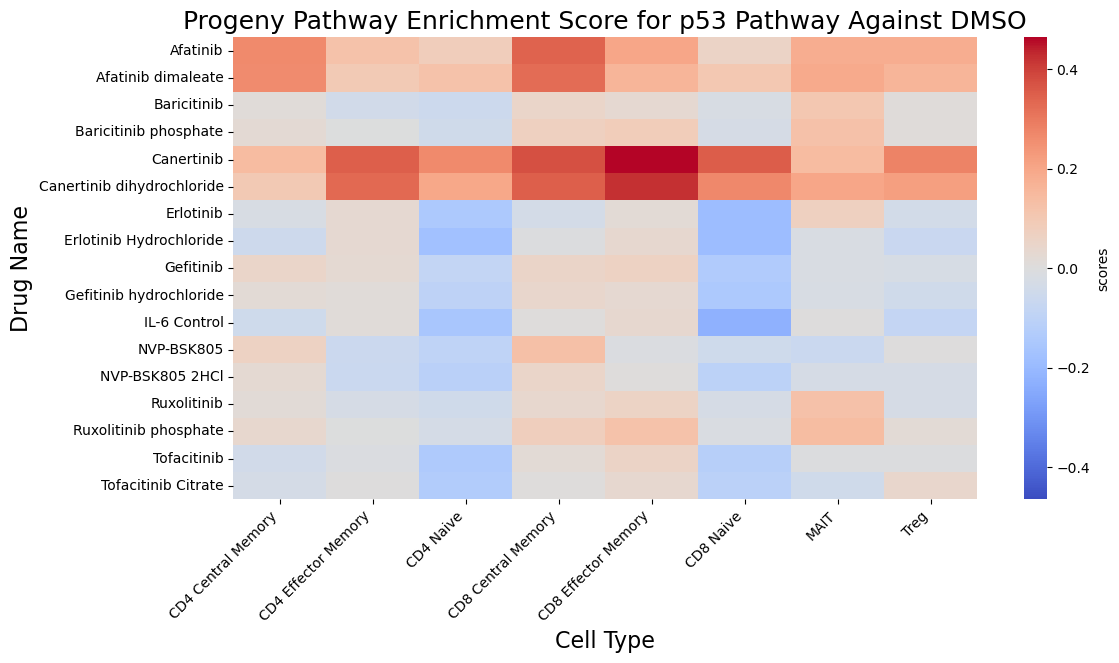

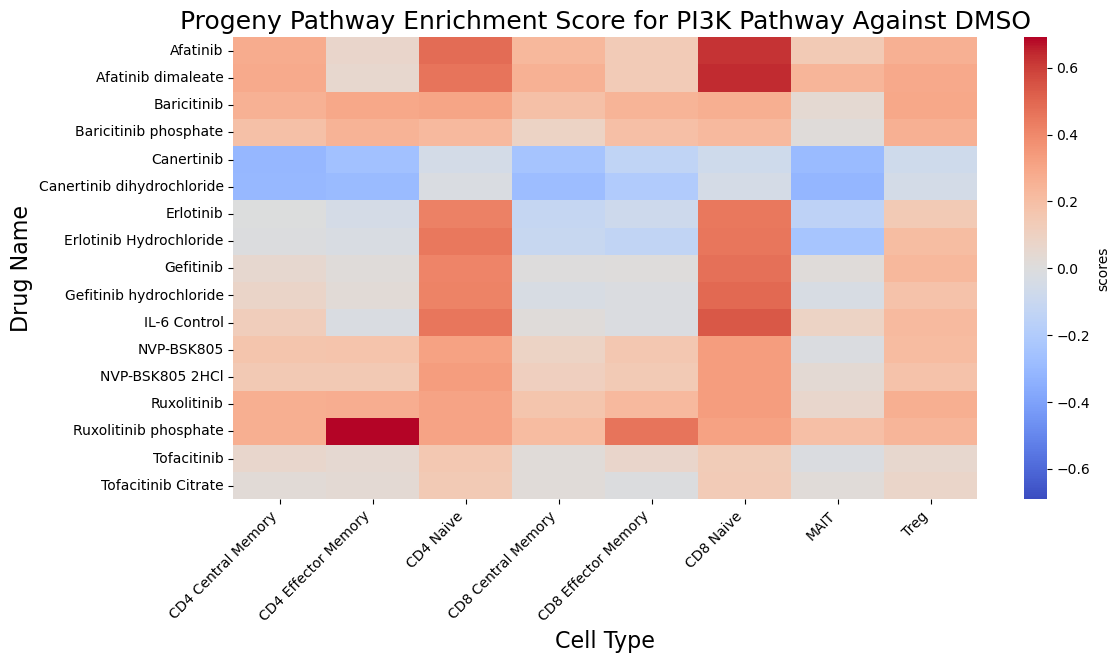

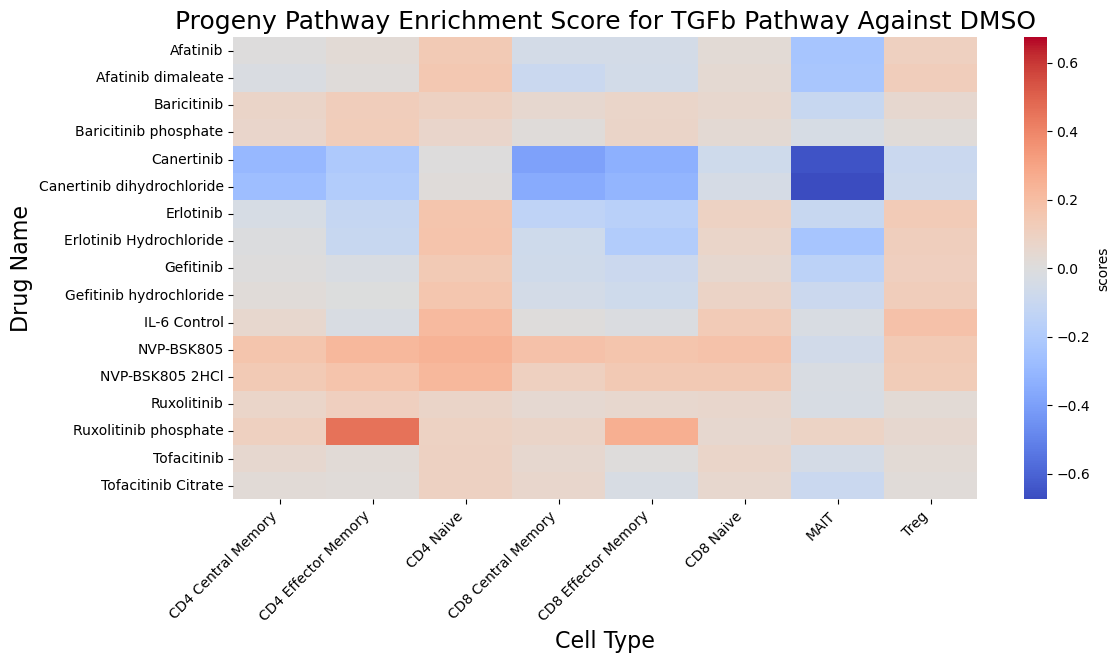

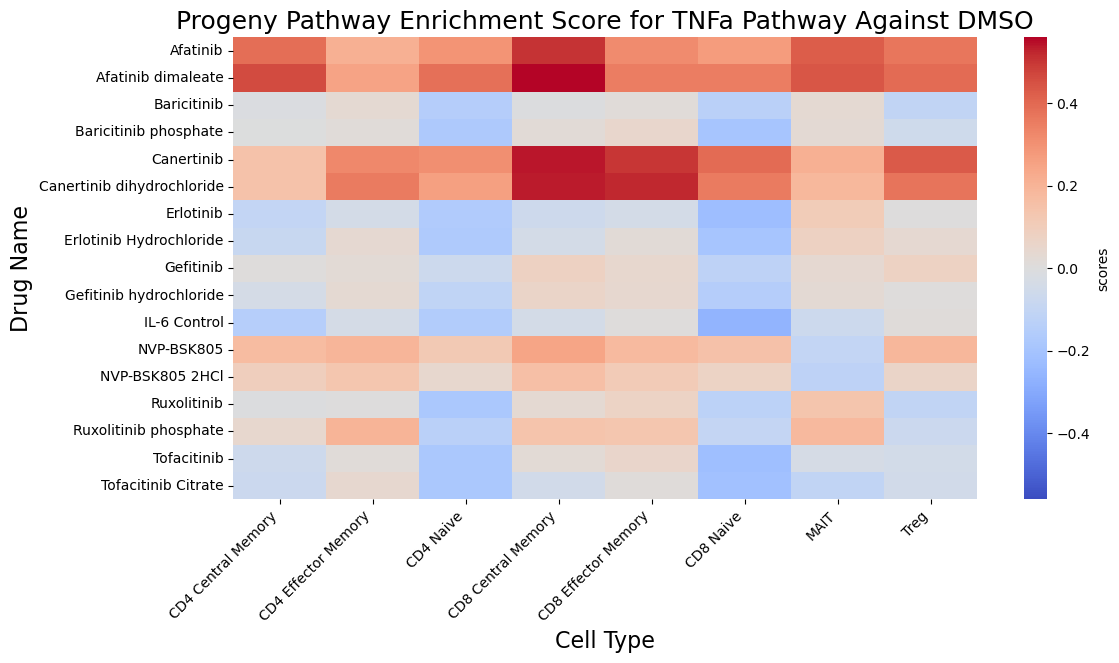

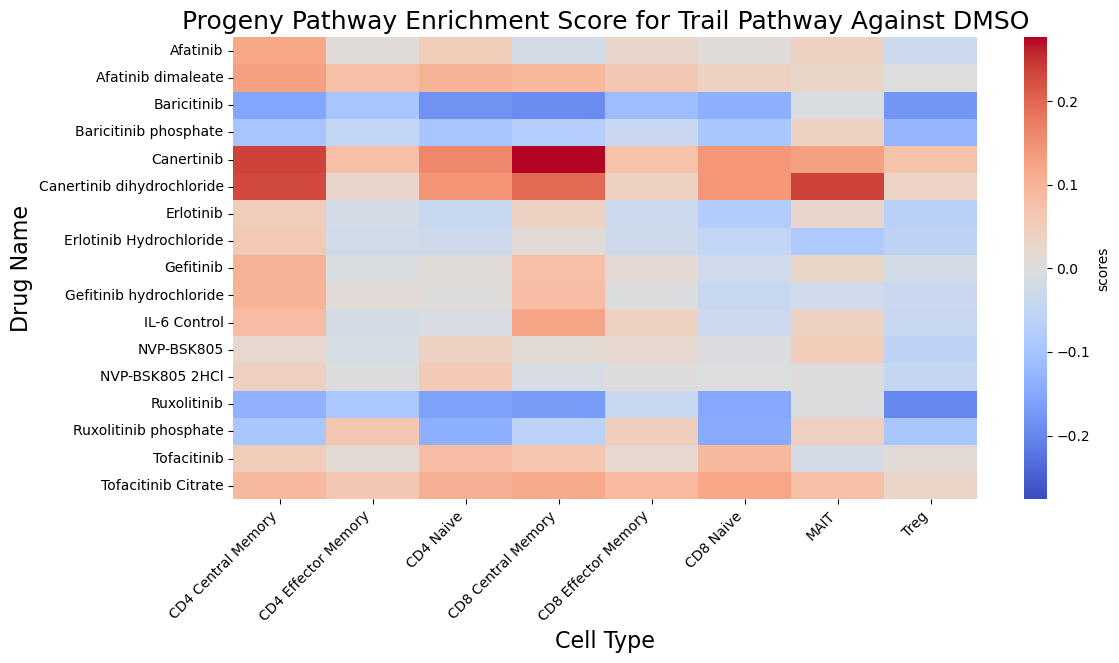

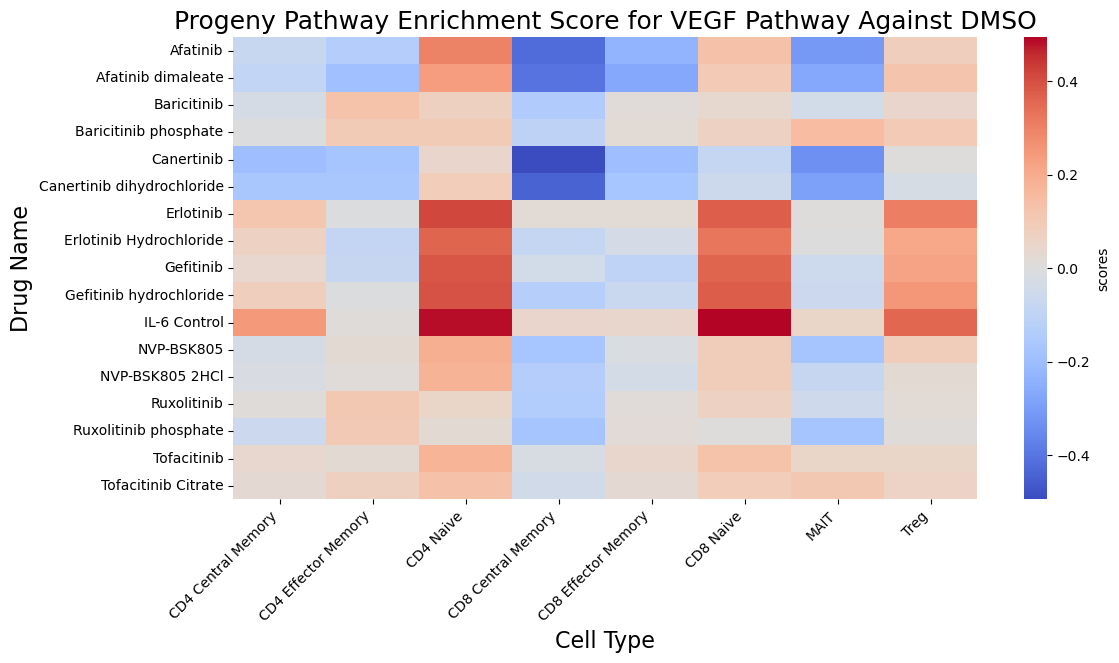

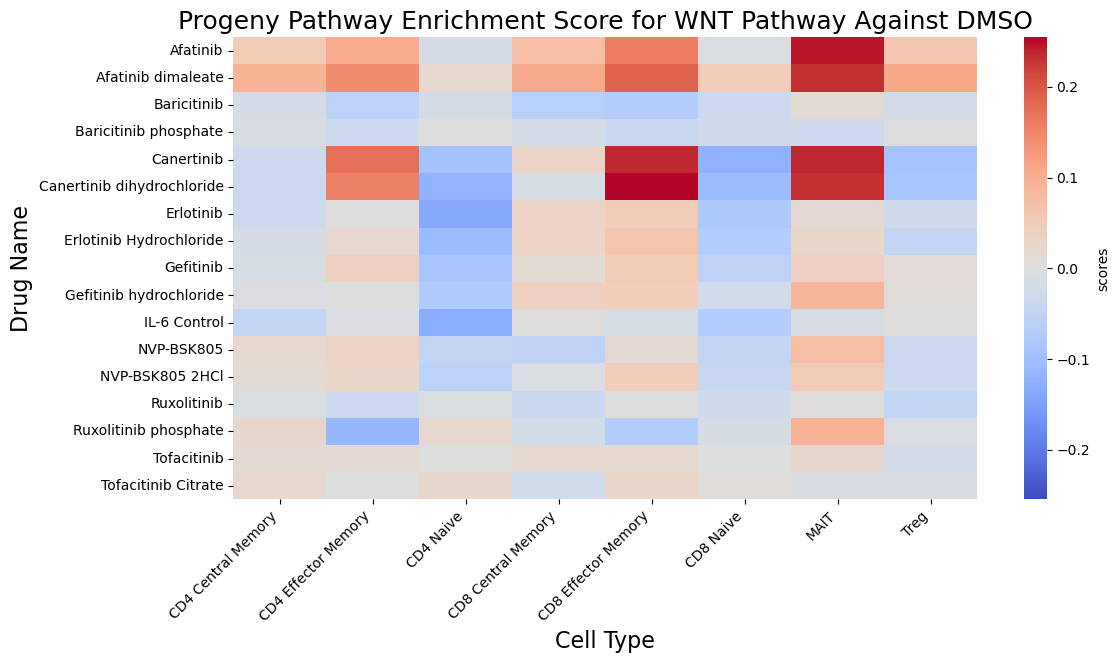

In [32]:
#Heat map: Create heat maps for each pathway (split by pathway) (one axis is cell type, one is drug name) 
#Focusing on JAK/STAT for example → good interpretation to look at just the JAK/STAT pathway to see how each drug changes for each cell type

for pathway in progeny_pathways:
    
    #getting only the rows with the pathway
    pathway_dataframe = all_results_progeny[all_results_progeny["name"] == pathway]

    #making the dataframe sutible for sns heatmap
    heatmap_df = pathway_dataframe.pivot_table(
        #the rows will be the drug type/treatment/name
        index="group",
        #the columns will be the cell type
        columns="cell_type",
        #the scores will be the pathway scores
        values="meanchange", 
        #this is to get rid of the warning
        observed=False)

    #this makes the scale of the bar symmetric (doesn't change the values) !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    vmax = np.nanmax(np.abs(heatmap_df.values))

    #plotting the heatmap
    plt.figure(figsize = (12, 6))
    sns.heatmap(data = heatmap_df, 
                #using coolwarm color
                cmap = "coolwarm",
                #centering it at 0, so 0 is white. eveyrthing above is red, everything below is blue
                center=0, 
                vmin=-vmax, #making the min value (-) max value !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                vmax=vmax, #making max value the max value!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                #scale lable
                cbar_kws={"label": "scores"})
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Progeny Pathway Enrichment Score for {pathway} Pathway Against DMSO", fontsize=18)
    plt.xlabel("Cell Type", fontsize=16)
    plt.ylabel("Drug Name", fontsize=16)
    plt.show()

### Violin Plots

In [33]:
adata

AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'
    varm: 'PCs'
    layers: 'counts', 'log_transformed'
    obsp: 'distances', 'connectivities'

In [34]:
# making a dictionary of subsetted data where the key is the cell type and the value is the anndata object
subsets_cells = {}

for cell_type in adata.obs['AIFI_L2'].unique():
    # print(f'current cell type is {cell_type}')
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()
    #running the rank gene groups
    sc.tl.rank_genes_groups(
        adata = cell_type_subset,
        groupby = "clean_drug_name",
        reference = "DMSO Control",
        method = "wilcoxon",
        layer = "log_transformed"
    )
    subsets_cells[cell_type] = cell_type_subset
subsets_cells

{'CD4 Central Memory': AnnData object with n_obs × n_vars = 107272 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
     uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon', 'rank_genes_groups'
     obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'
     varm: 'PCs'
     layers: 'counts', 'log_transformed'
     obsp: 'distances', 'connectivities',
 'CD8 Naive': AnnData object with n_obs × n_vars = 78553 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', '

In [49]:
#making dictionary to hold cell type and their scores (key is cell type, value is score andata object)
subset_cell_progney_scores = {}

for cell_type, subset_cell in subsets_cells.items():    
    # print(f"THE CELL TYPE IS: {cell_type}")
    # print(subset_cell)
    #computing pathway scores for each celll
    dc.mt.ulm(data=subset_cell, net=progeny)
    
    # print("THE SCORE ANNDATA IS:")
    #extracting the scores
    score = dc.pp.get_obsm(adata=subset_cell, key="score_ulm")
    # print(score)
    
    # print(" ")

    #adding the info to the dictionary
    subset_cell_progney_scores[cell_type] = score

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


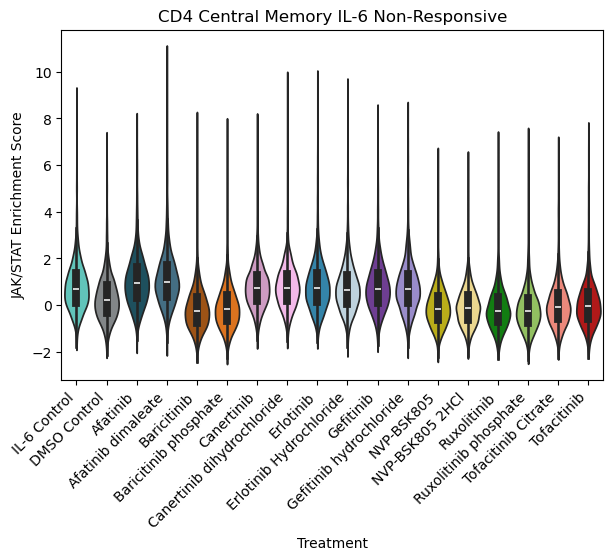

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


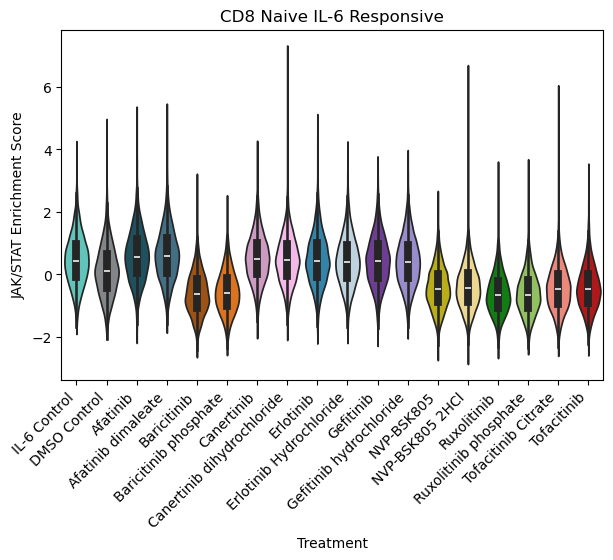

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


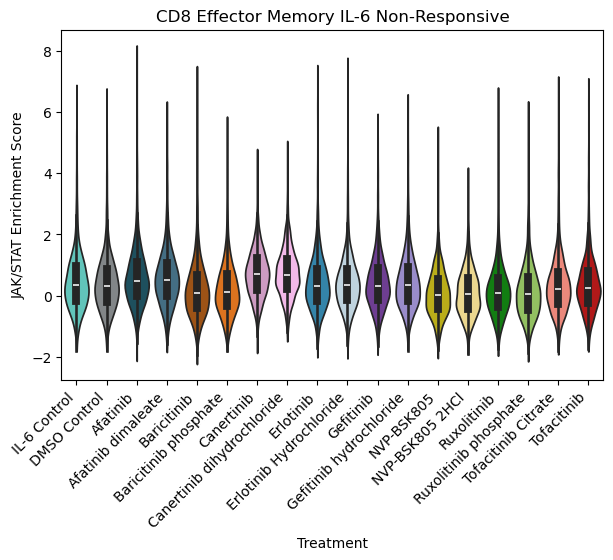

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


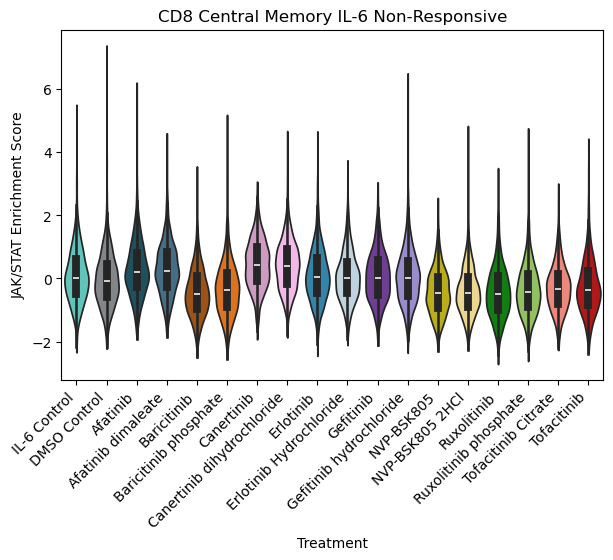

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


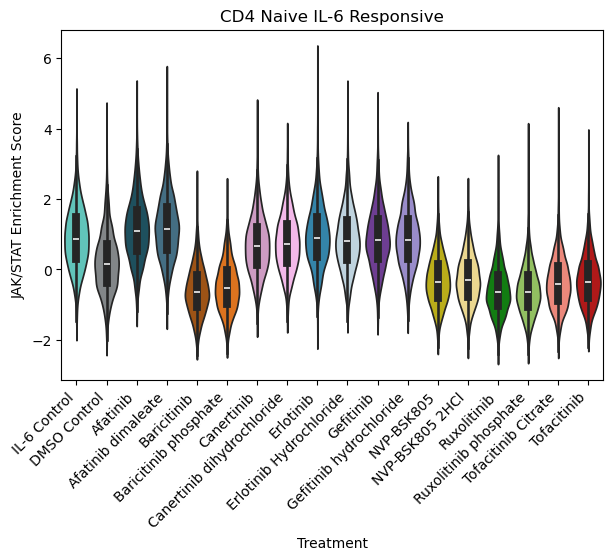

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


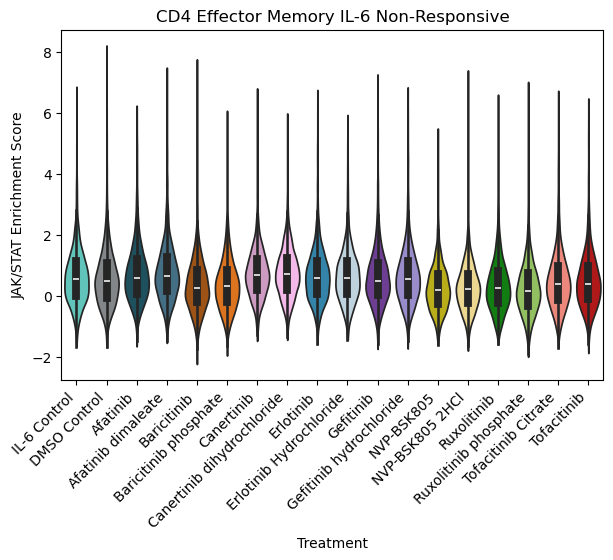

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


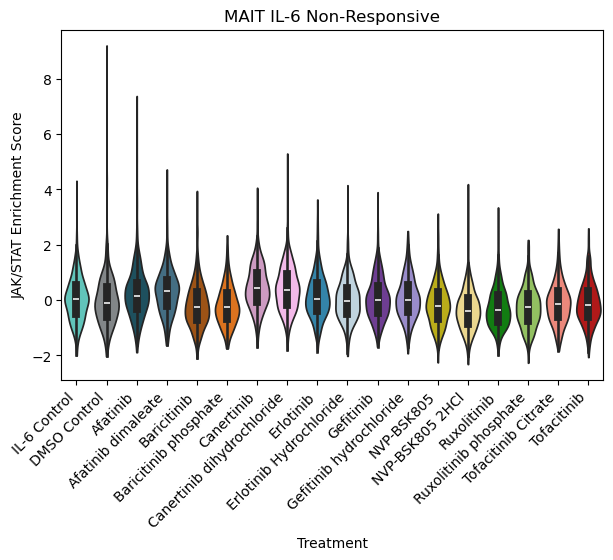

/tmp/ipykernel_102/3916456519.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_102/3916456519.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


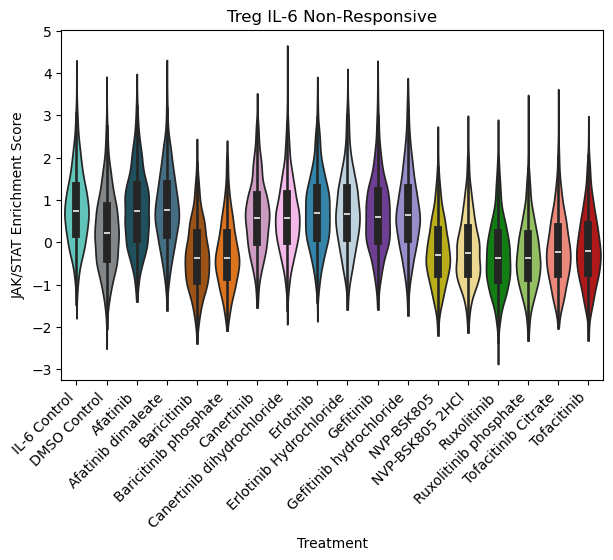

In [48]:
#looping through the cell type and scored adata object
for cell_type, subset_cell_score in subset_cell_progney_scores.items():    
    # print(cell_type)

    #create the violin plot
    ax = sc.pl.violin(
        subset_cell_score,
        stripplot=False,
        inner="box",
        keys=["JAK-STAT"],
        groupby="clean_drug_name",
        show=False
    )

    #rotating the x axis lables
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Set axis labels
    ax.set_xlabel("Treatment")
    ax.set_ylabel("JAK/STAT Enrichment Score")

    #title labeling based on cell type
    if "Naive" in cell_type:
        #title is the cell type
        ax.set_title(f"{cell_type} IL-6 Responsive")
    
    else:
        ax.set_title(f"{cell_type} IL-6 Non-Responsive")


    #limmiting the white space
    plt.tight_layout()
    
    #showing the figure
    plt.show()

    #saving the figure!
    ax.figure.savefig(
        f"progeny_{cell_type}_violin_plot.svg",
        dpi=300,
        bbox_inches="tight"
        )


## Pathway Scoring with Hallmark

Hallmark gene sets are curated collections of genes that represent specific, well-defined biological states or processes. They are part of MSigDB and were developed to reduce redundancy and improve interpretability compared to older, more overlapping gene set collections

In [26]:
#accessing it
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [27]:
# look into these, one might go down: 'TGF_BETA_SIGNALING', 'TNFA_SIGNALING_VIA_NFKB'
# 'IL2_STAT5_SIGNALING'
hallmark_pathways = ['IL6_JAK_STAT3_SIGNALING', 'IL2_STAT5_SIGNALING',
                     'TGF_BETA_SIGNALING', 'TNFA_SIGNALING_VIA_NFKB',
                     'ADIPOGENESIS', 'ALLOGRAFT_REJECTION', 
                     'ANDROGEN_RESPONSE', 'ANGIOGENESIS', 'APICAL_JUNCTION', 
                     'APICAL_SURFACE', 'APOPTOSIS', 'BILE_ACID_METABOLISM', 
                     'CHOLESTEROL_HOMEOSTASIS', 'COAGULATION', 'COMPLEMENT', 
                     'DNA_REPAIR', 'E2F_TARGETS', 'EPITHELIAL_MESENCHYMAL_TRANSITION', 
                     'ESTROGEN_RESPONSE_EARLY', 'ESTROGEN_RESPONSE_LATE', 
                     'FATTY_ACID_METABOLISM', 'G2M_CHECKPOINT',
                     'GLYCOLYSIS', 'HEDGEHOG_SIGNALING', 'HEME_METABOLISM', 'HYPOXIA',
                     'INFLAMMATORY_RESPONSE', 'INTERFERON_ALPHA_RESPONSE',
                     'INTERFERON_GAMMA_RESPONSE', 'KRAS_SIGNALING_DN', 'KRAS_SIGNALING_UP',
                     'MITOTIC_SPINDLE', 'MTORC1_SIGNALING', 'MYC_TARGETS_V1',
                     'MYC_TARGETS_V2', 'MYOGENESIS', 'NOTCH_SIGNALING',
                     'OXIDATIVE_PHOSPHORYLATION', 'P53_PATHWAY', 'PANCREAS_BETA_CELLS',
                     'PEROXISOME', 'PI3K_AKT_MTOR_SIGNALING', 'PROTEIN_SECRETION',
                     'REACTIVE_OXYGEN_SPECIES_PATHWAY', 'SPERMATOGENESIS',
                     'UNFOLDED_PROTEIN_RESPONSE', 'UV_RESPONSE_DN', 'UV_RESPONSE_UP',
                     'WNT_BETA_CATENIN_SIGNALING', 'XENOBIOTIC_METABOLISM']

### Scores for the entire adata object

In [28]:
#calculating pathway scores
dc.mt.ulm(data=adata, net=hallmark)

In [29]:
#extracting scores
score_hallmark = dc.pp.get_obsm(adata=adata, key="score_ulm")
score_hallmark

AnnData object with n_obs × n_vars = 449975 × 50
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'

In [30]:
#making empty distionary where key will be there 
cell_type_results = {}

#looping through the cell types in the adata object column
for cell_type in adata.obs['AIFI_L2'].unique():    
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()

    #getting the enrichment score
    score = dc.pp.get_obsm(cell_type_subset, key="score_ulm")

    #running rankby group against the DMSO Control
    df = dc.tl.rankby_group(
        adata=score, 
        groupby="clean_drug_name", 
        reference="DMSO Control", 
        method="wilcoxon"
    )

    #adding the cell type name to a data frame (adding a column)
    df['cell_type'] = cell_type

    #adding the rest of the stats to the dataframe
    cell_type_results[cell_type] = df

#concatinating all of the results
all_results_hallmark = pd.concat(cell_type_results)

In [31]:
all_results_hallmark

group     reference  \
CD4 Central Memory 0       Afatinib  DMSO Control   
                   1       Afatinib  DMSO Control   
                   2       Afatinib  DMSO Control   
                   3       Afatinib  DMSO Control   
                   4       Afatinib  DMSO Control   
...                             ...           ...   
Treg               845  Tofacitinib  DMSO Control   
                   846  Tofacitinib  DMSO Control   
                   847  Tofacitinib  DMSO Control   
                   848  Tofacitinib  DMSO Control   
                   849  Tofacitinib  DMSO Control   

                                                   name       stat  \
CD4 Central Memory 0    REACTIVE_OXYGEN_SPECIES_PATHWAY  40.402248   
                   1          INTERFERON_GAMMA_RESPONSE  39.048731   
                   2                IL2_STAT5_SIGNALING  26.933135   
                   3            TNFA_SIGNALING_VIA_NFKB  23.673792   
                   4          INTERFERON_ALPHA_RESPONSE  23.474079   
...                                                 ...        ...   
Treg               845              PANCREAS_BETA_CELLS   0.347530   
                   846                       COMPLEMENT  -0.066217   
                   847                  SPERMATOGENESIS  -0.042178   
                   848             BILE_ACID_METABOLISM   0.019832   
                   849                PROTEIN_SECRETION   0.016390   

                        meanchange           pval           padj  \
CD4 Central Memory 0      0.691406   0.000000e+00   0.000000e+00   
                   1      0.751894   0.000000e+00   0.000000e+00   
                   2      0.462884  8.990836e-160  1.498473e-158   
                   3      0.628028  6.715448e-124  8.394310e-123   
                   4      0.428888  7.505986e-122  7.505986e-121   
...                            ...            ...            ...   
Treg               845    0.008429   7.281934e-01   7.915145e-01   
                   846   -0.001372   9.472051e-01   9.869230e-01   
                   847   -0.011341   9.663570e-01   9.869230e-01   
                   848    0.001947   9.841771e-01   9.869230e-01   
                   849   -0.004067   9.869230e-01   9.869230e-01   

                                 cell_type  
CD4 Central Memory 0    CD4 Central Memory  
                   1    CD4 Central Memory  
                   2    CD4 Central Memory  
                   3    CD4 Central Memory  
                   4    CD4 Central Memory  
...                                    ...  
Treg               845                Treg  
                   846                Treg  
                   847                Treg  
                   848                Treg  
                   849                Treg  

[6800 rows x 8 columns]

### Heatmap

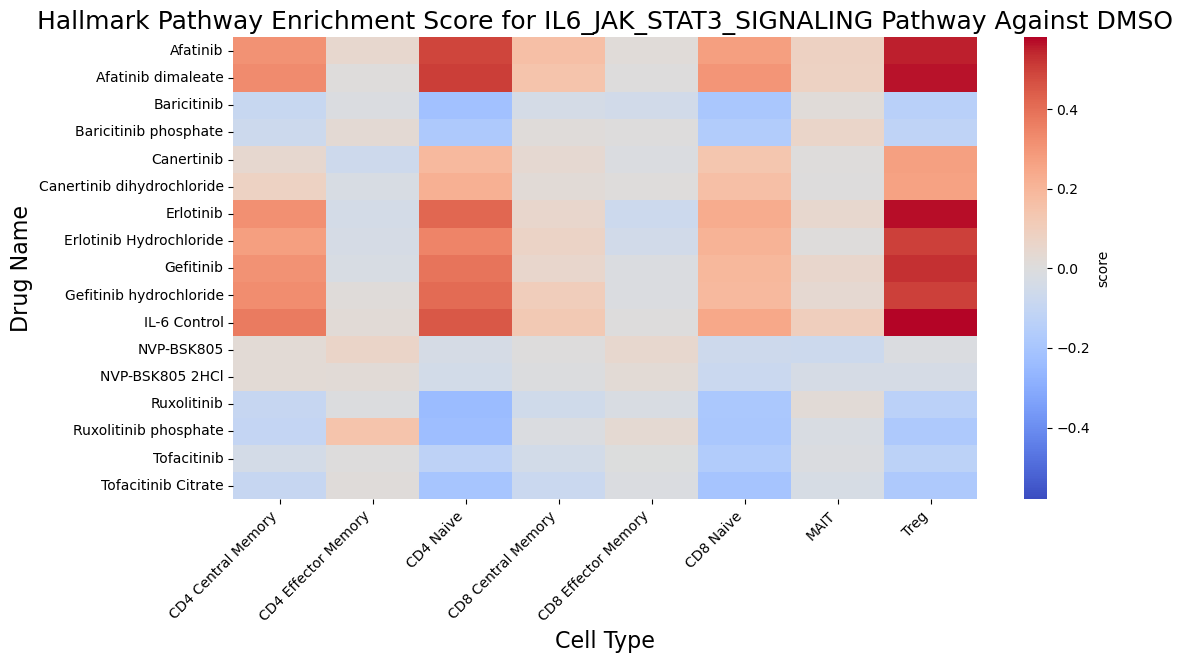

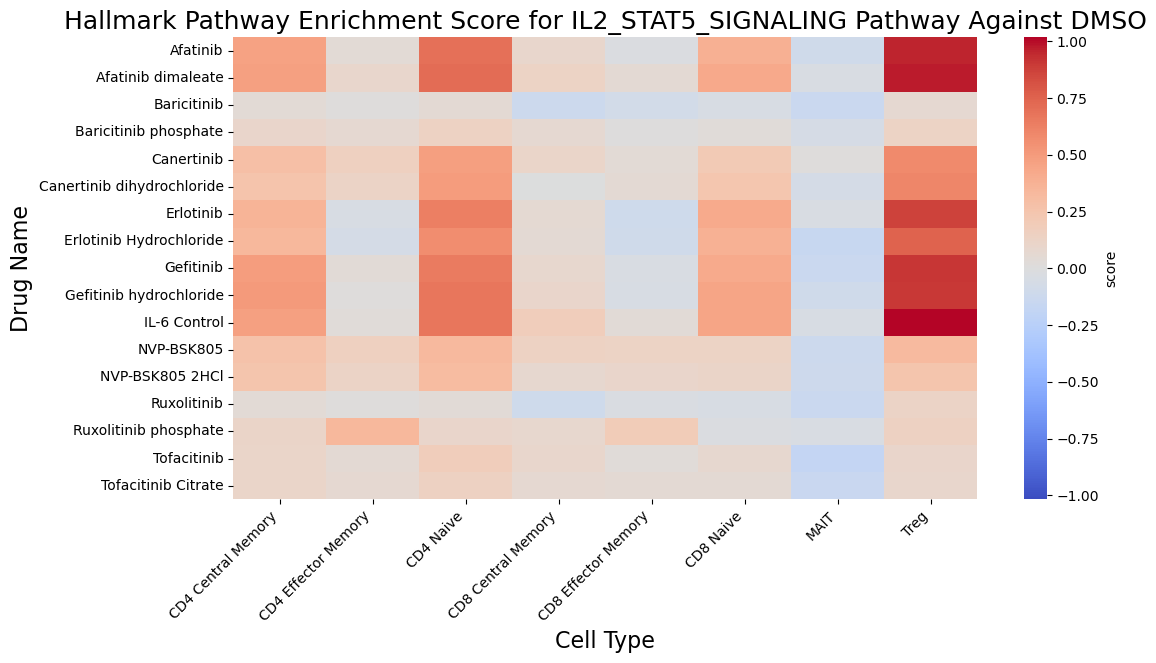

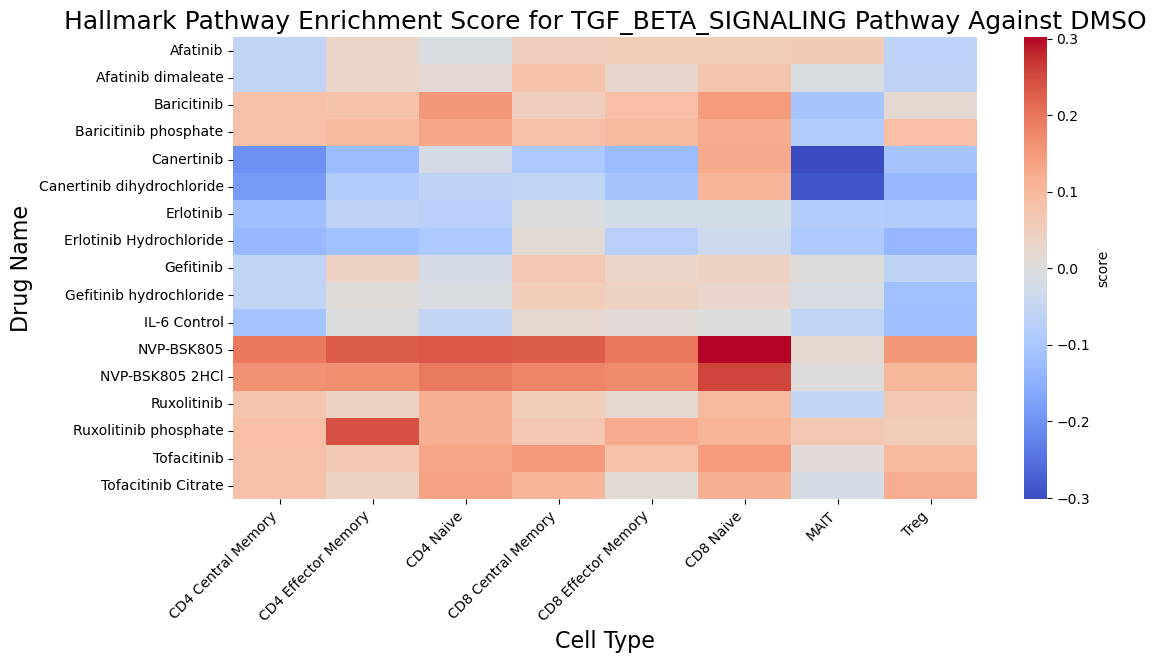

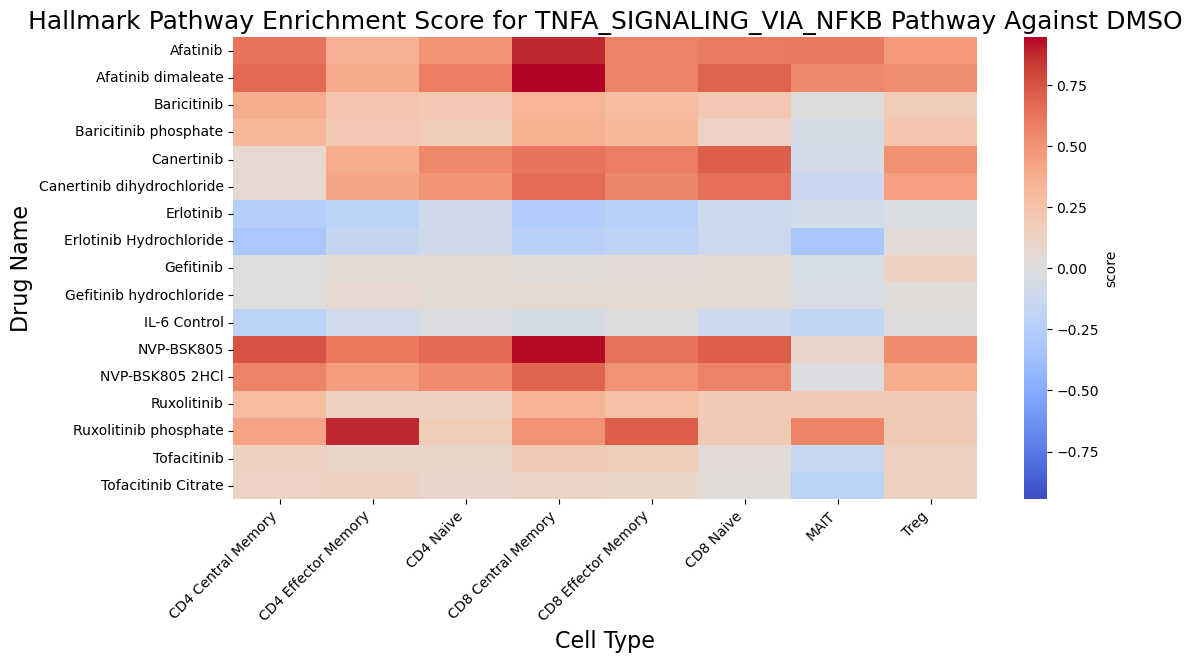

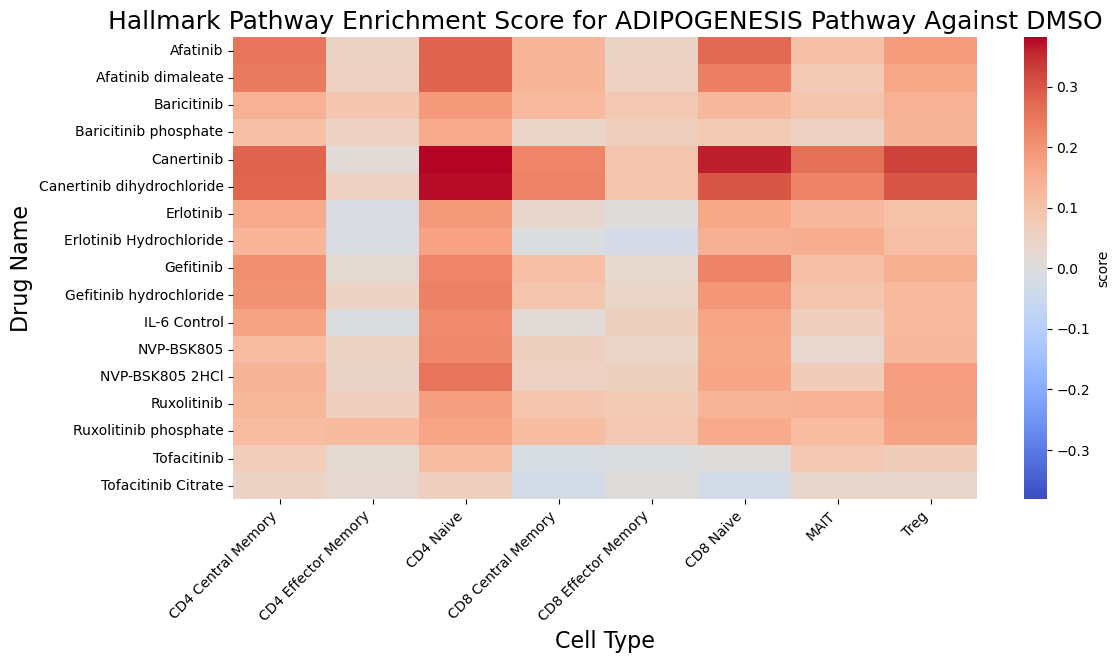

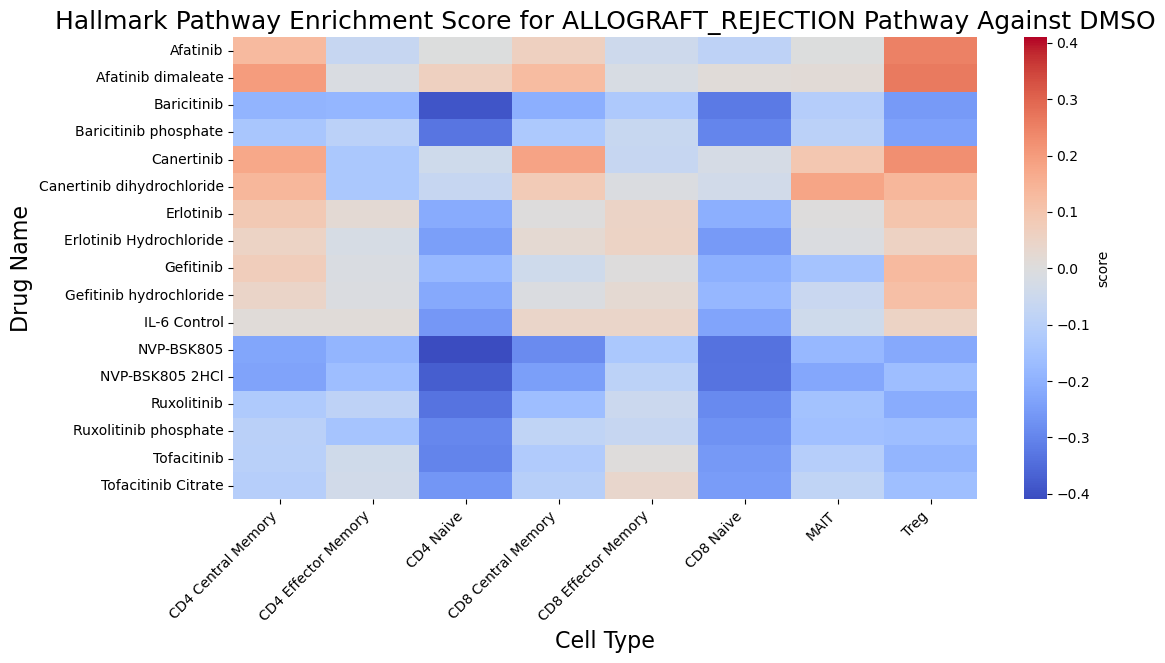

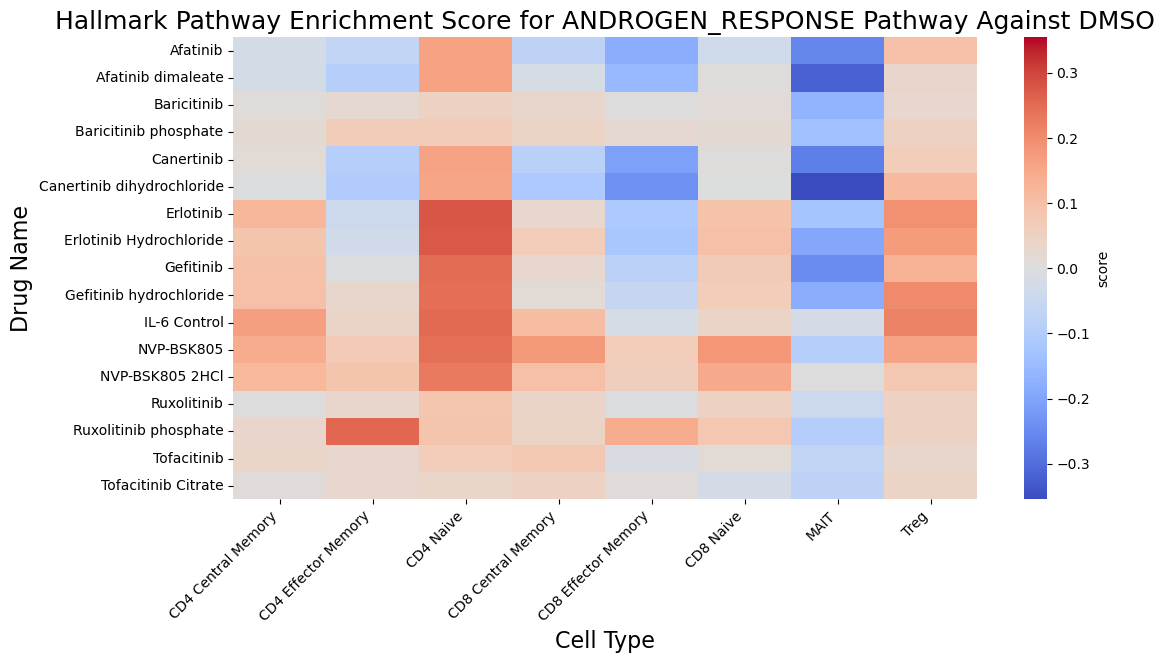

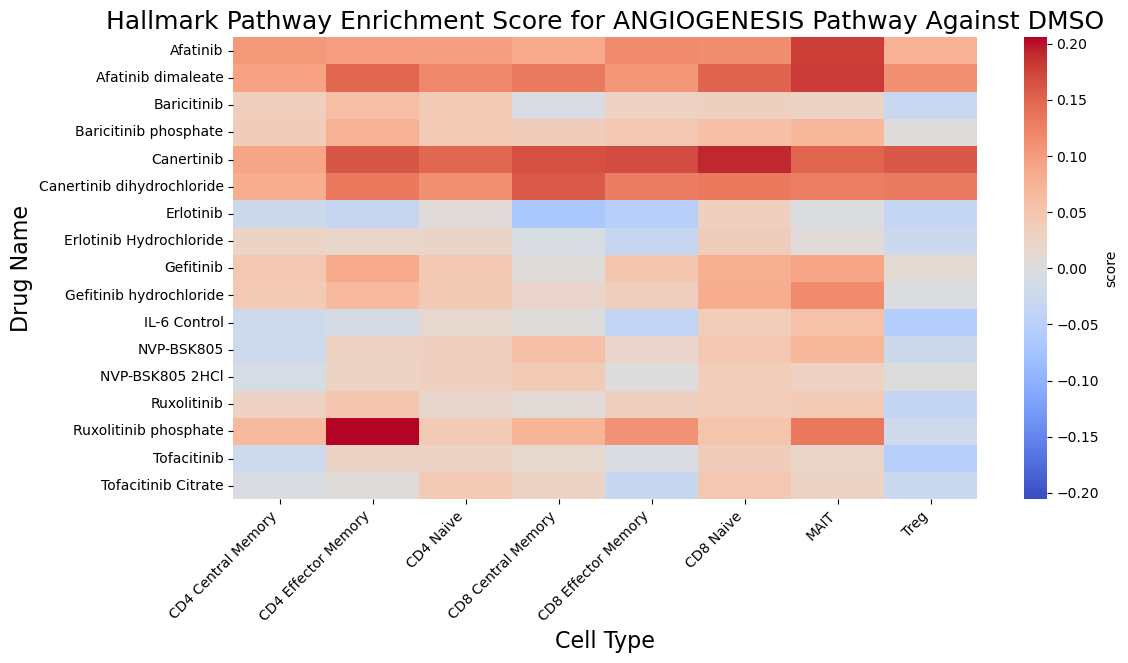

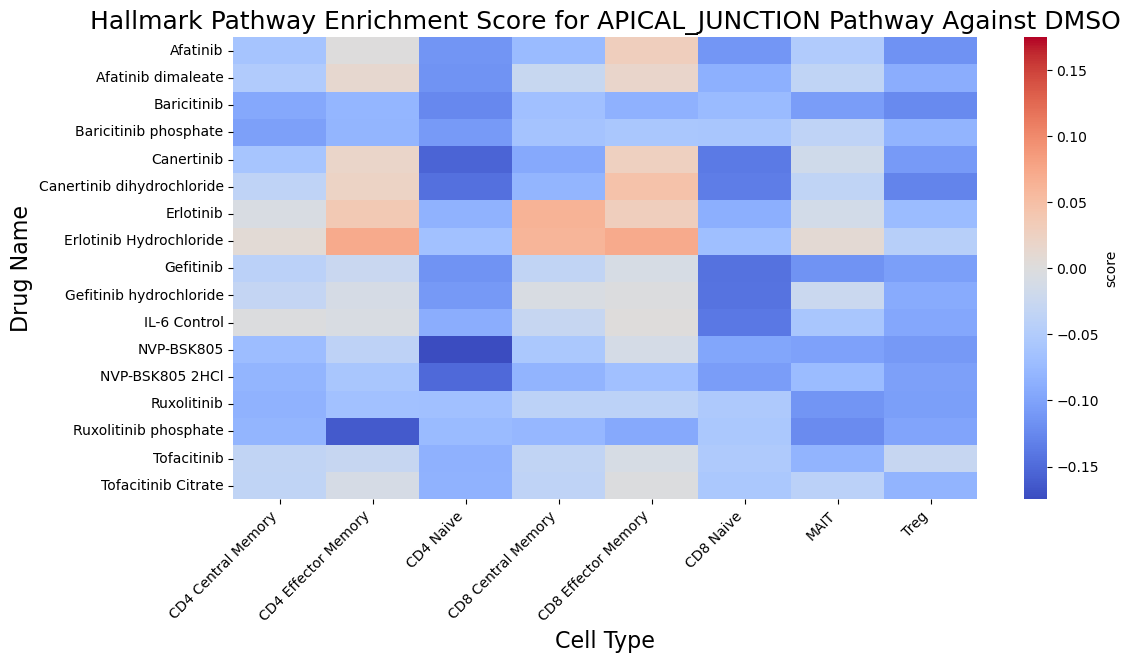

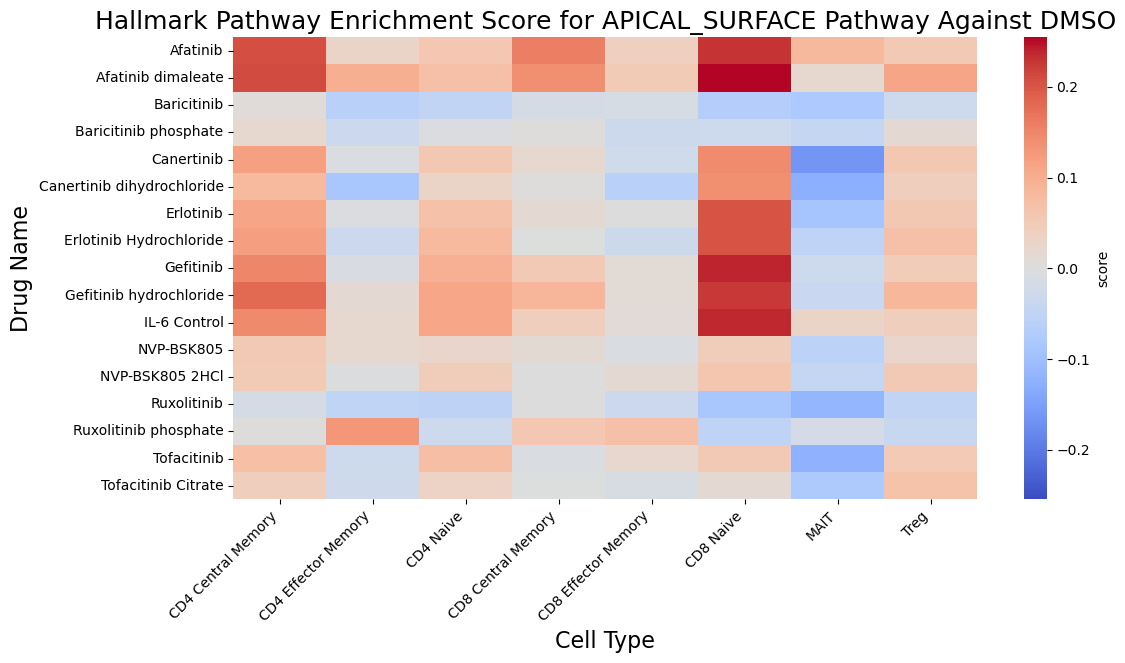

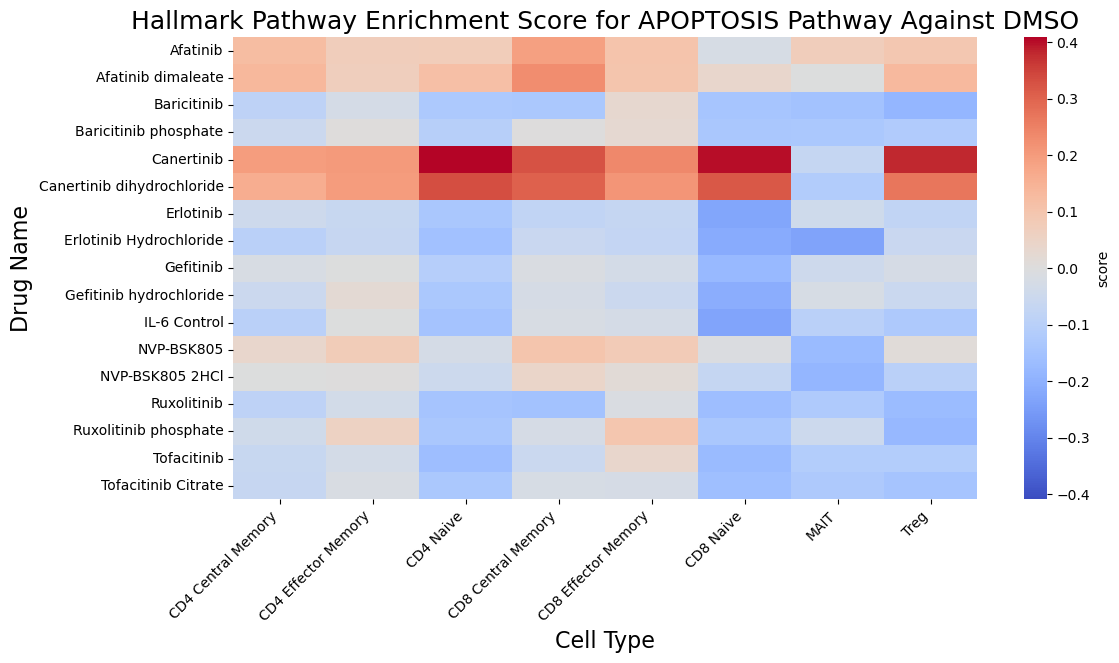

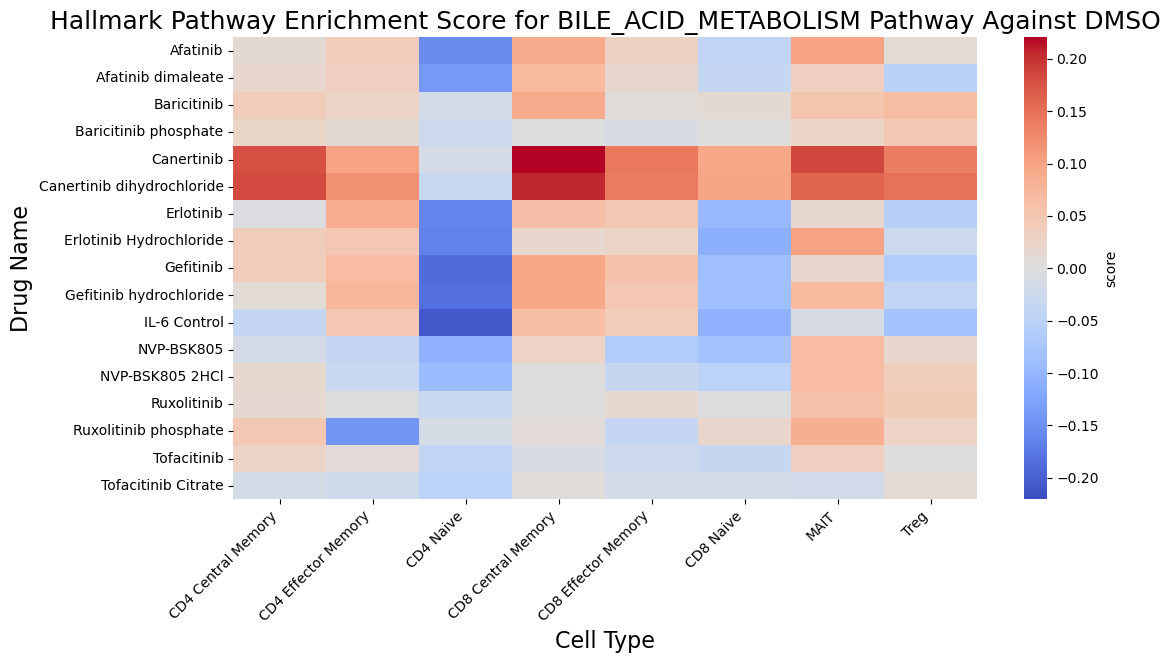

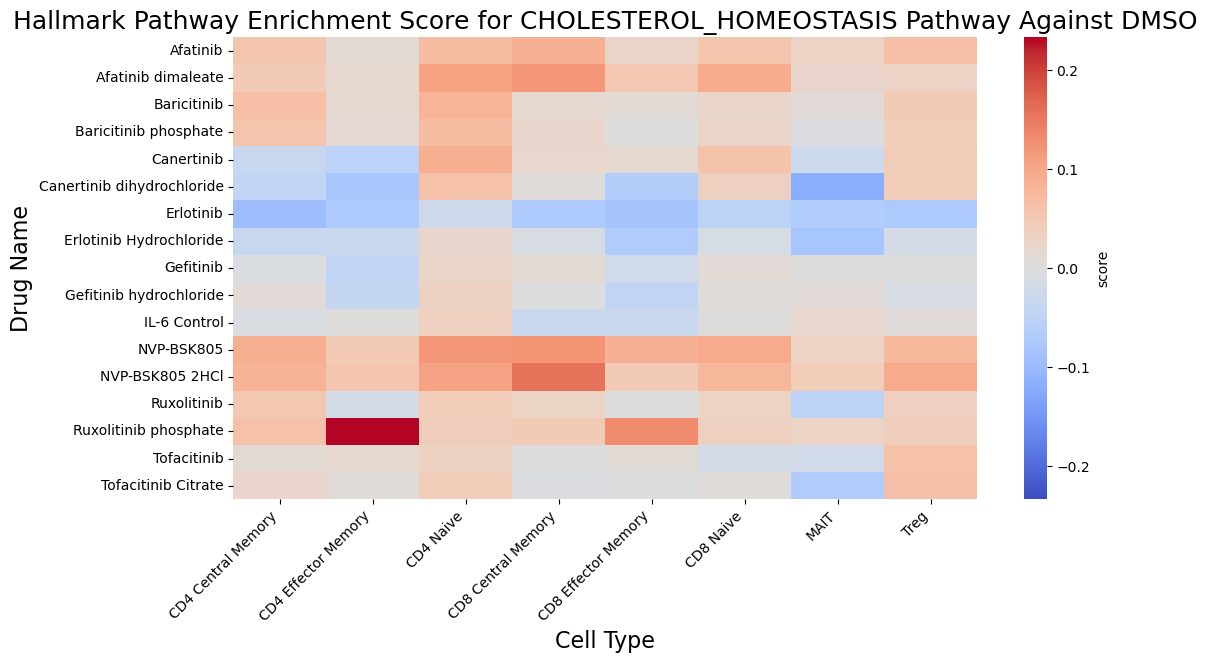

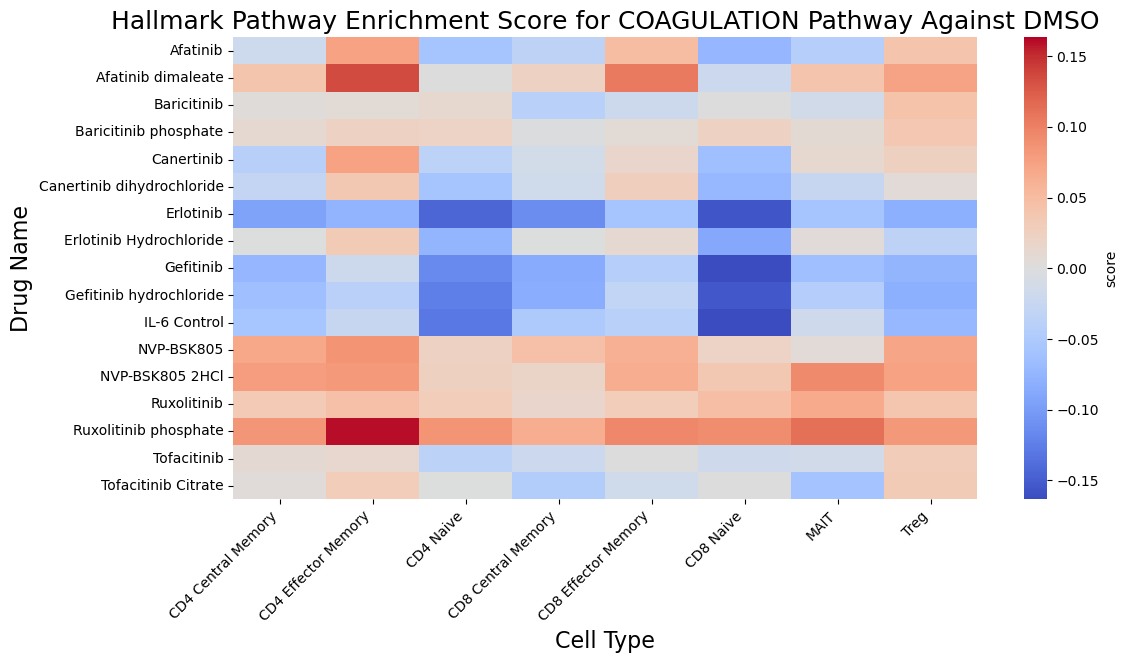

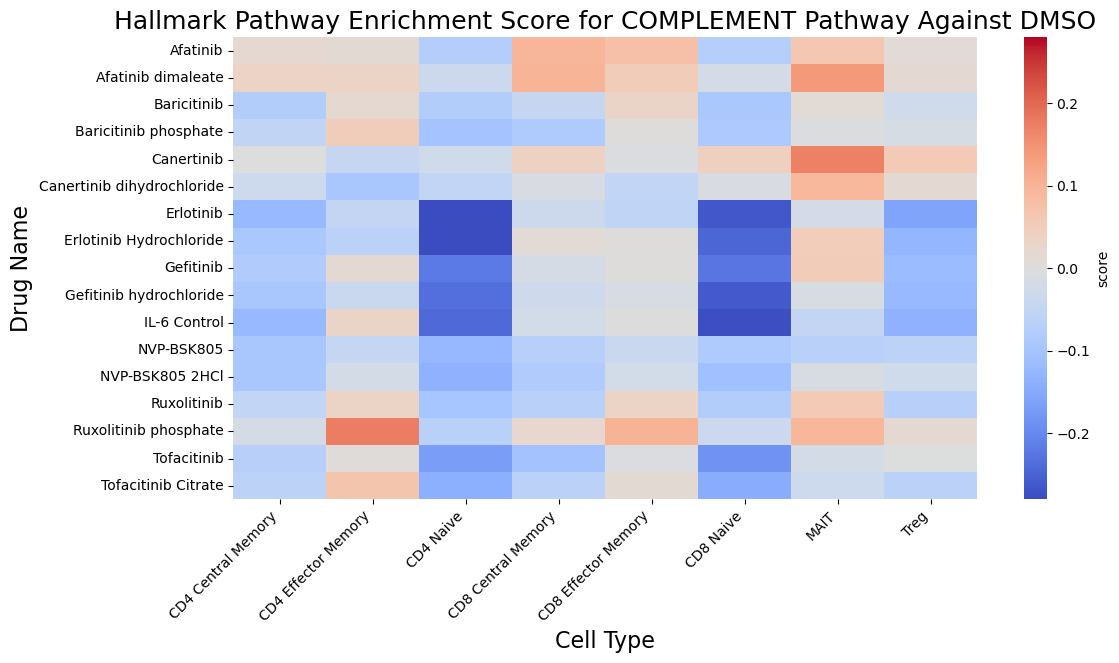

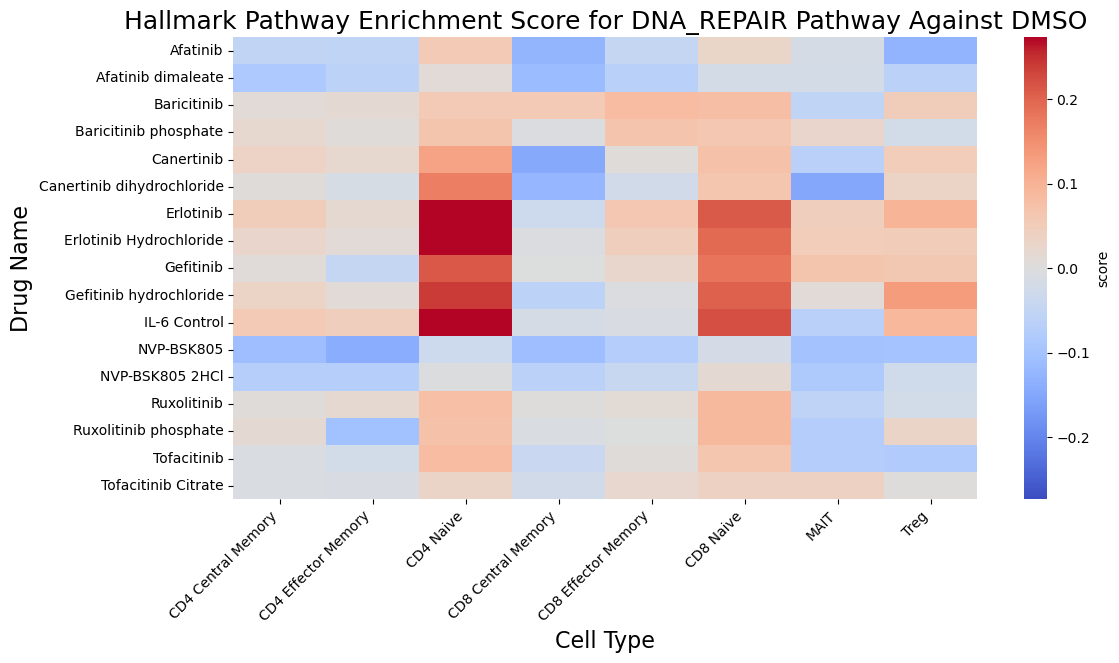

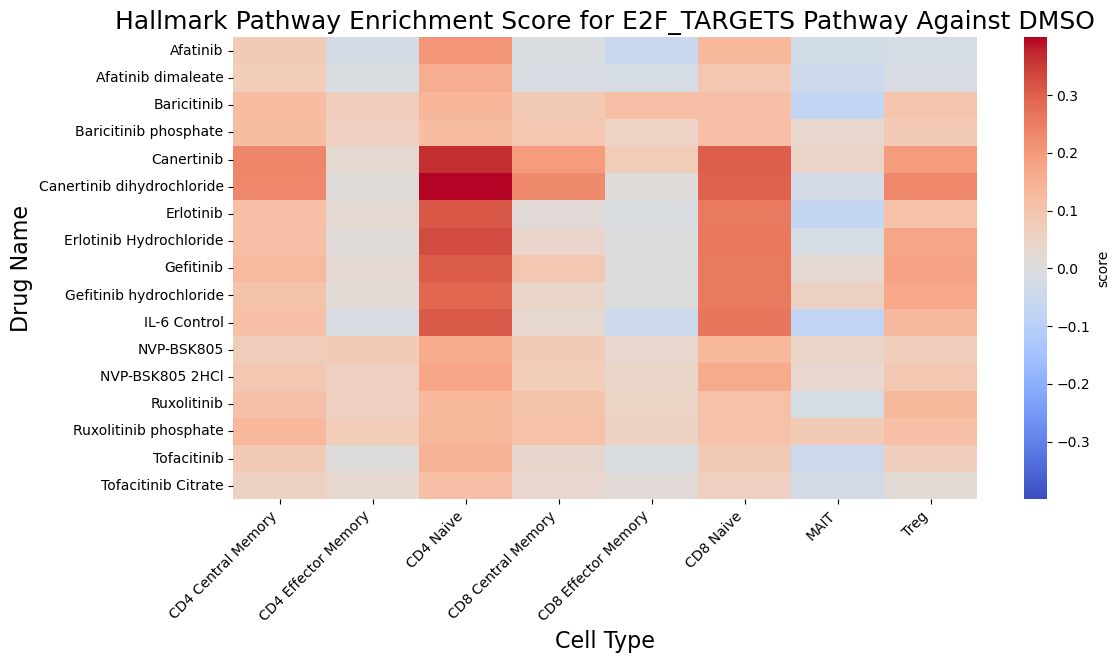

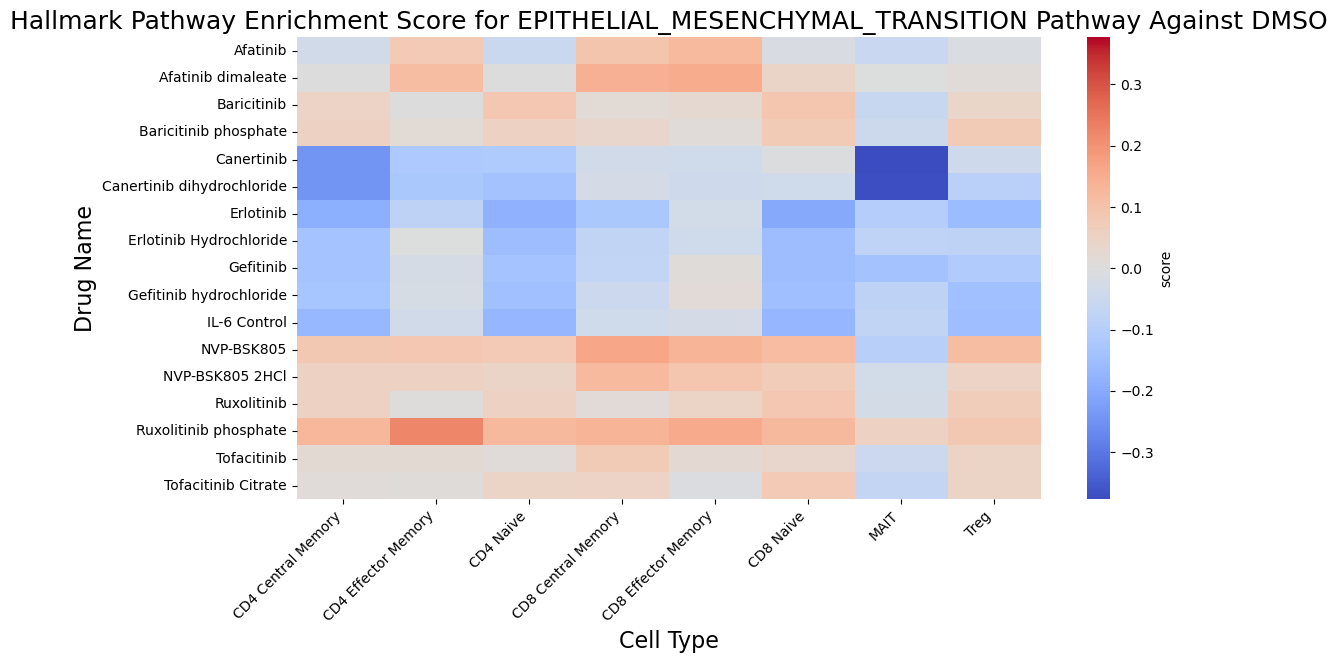

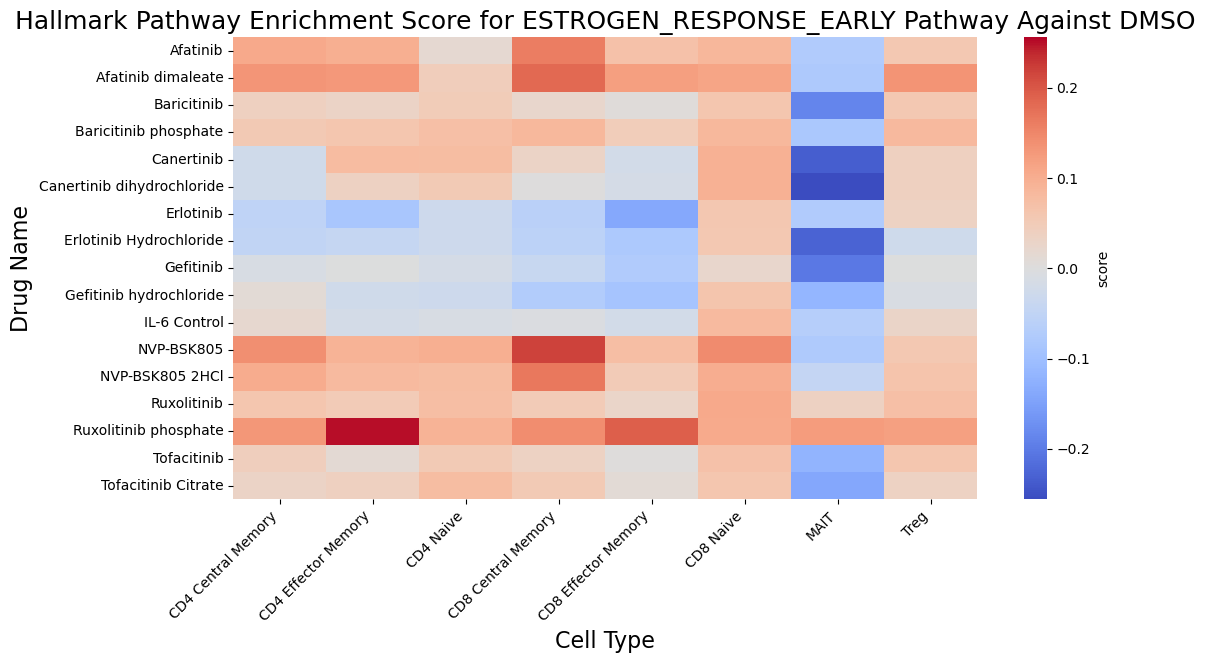

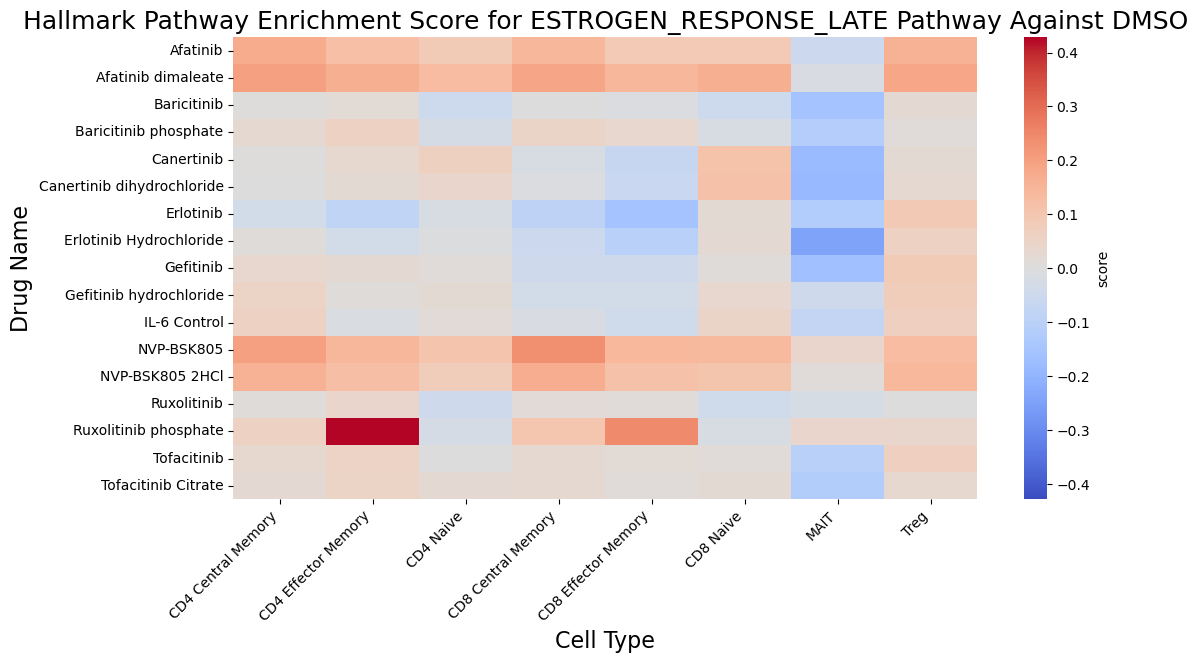

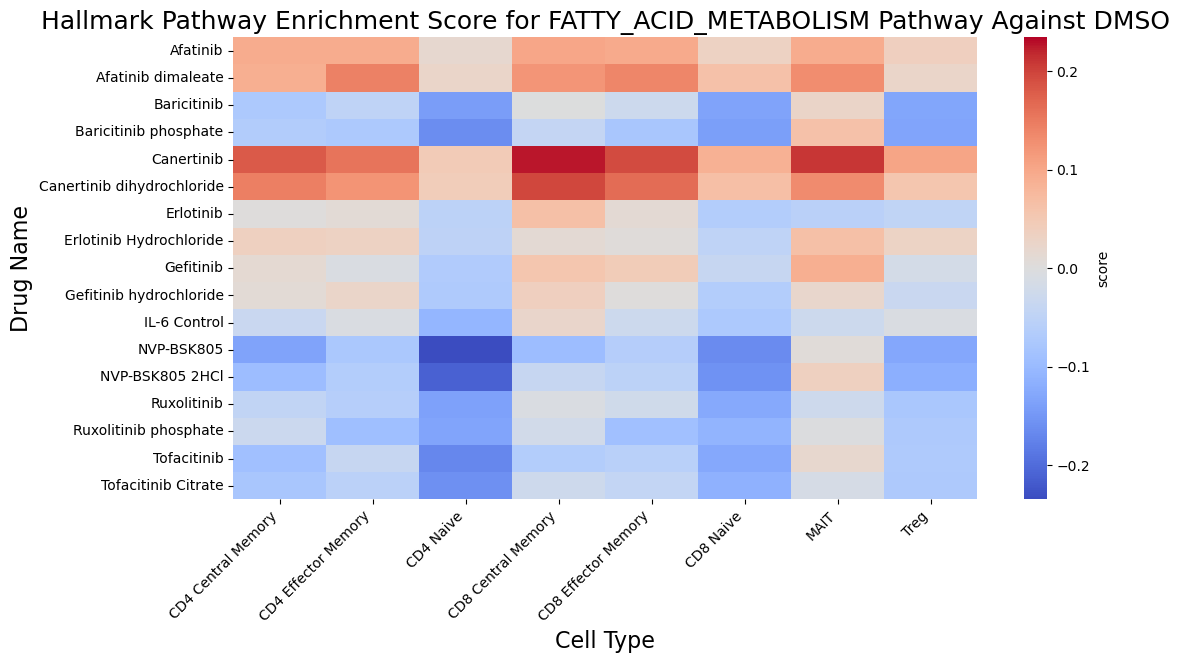

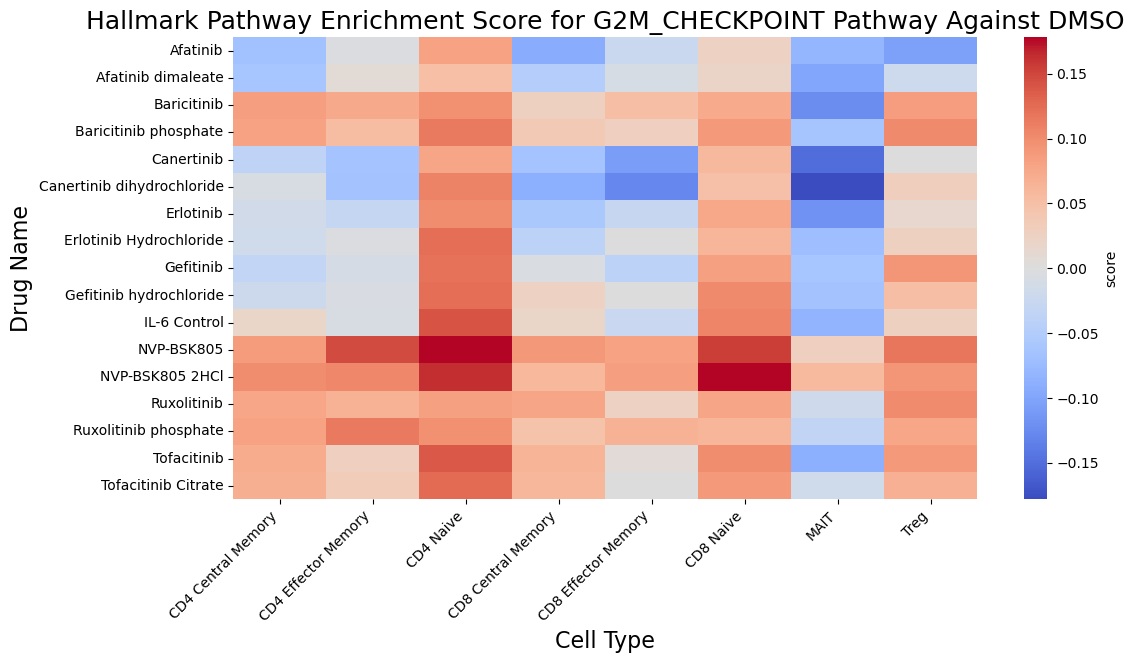

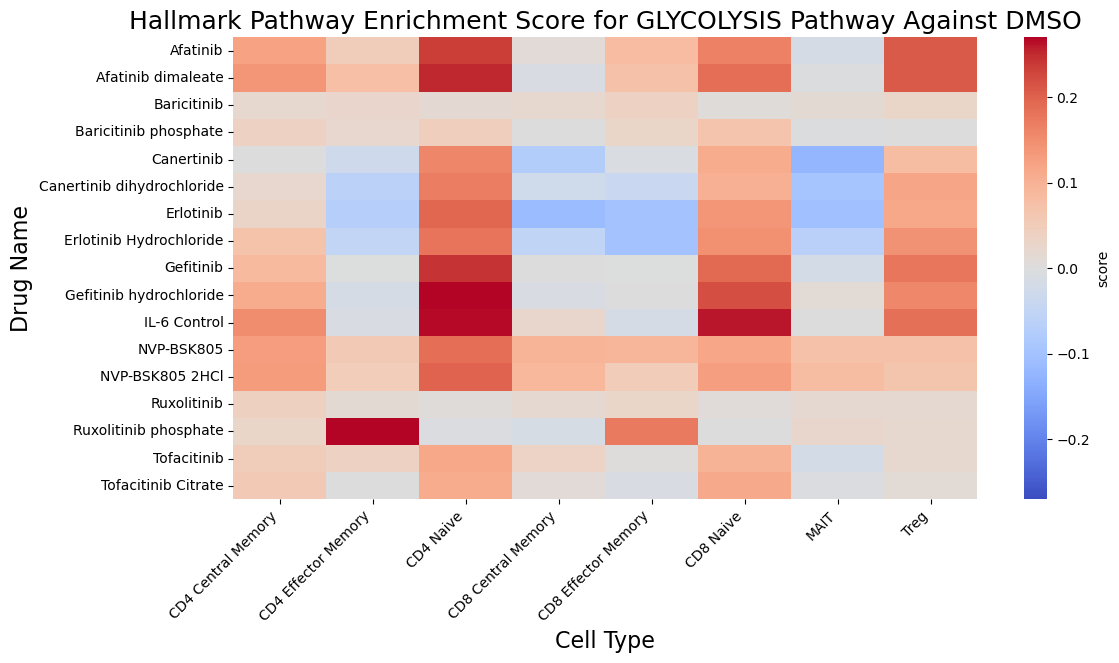

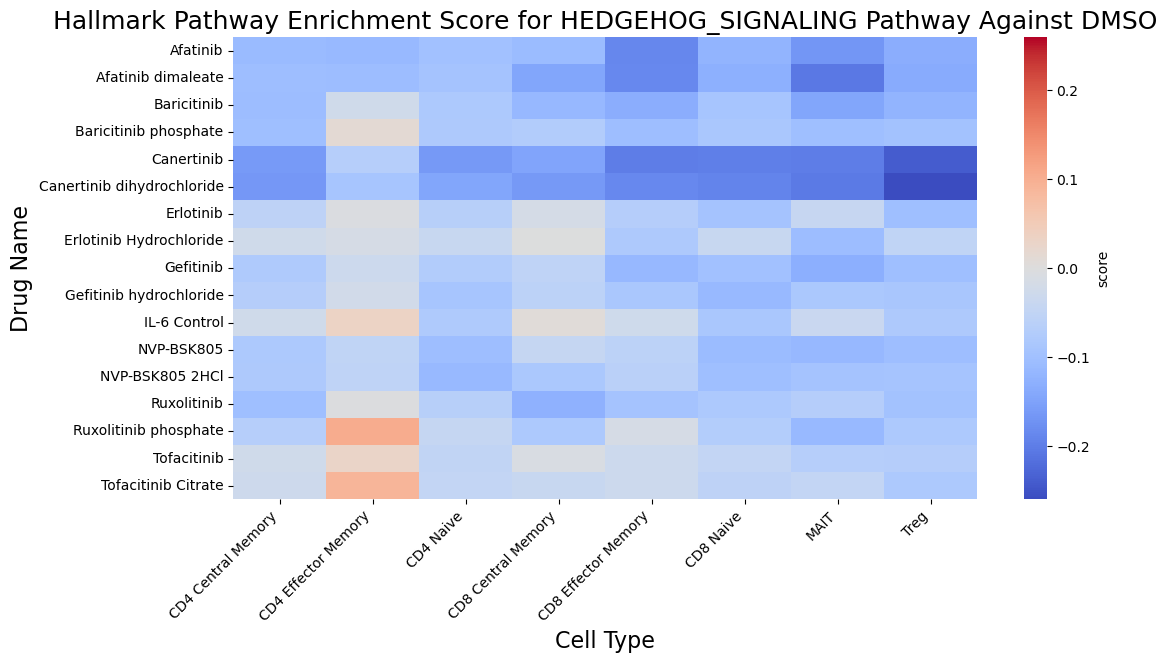

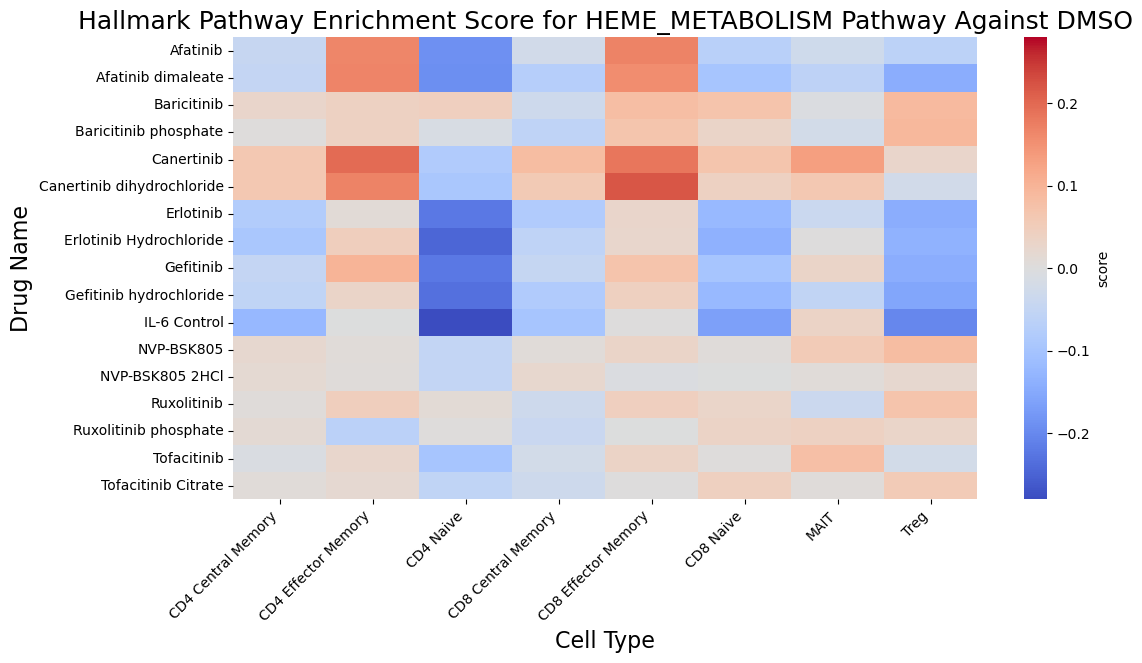

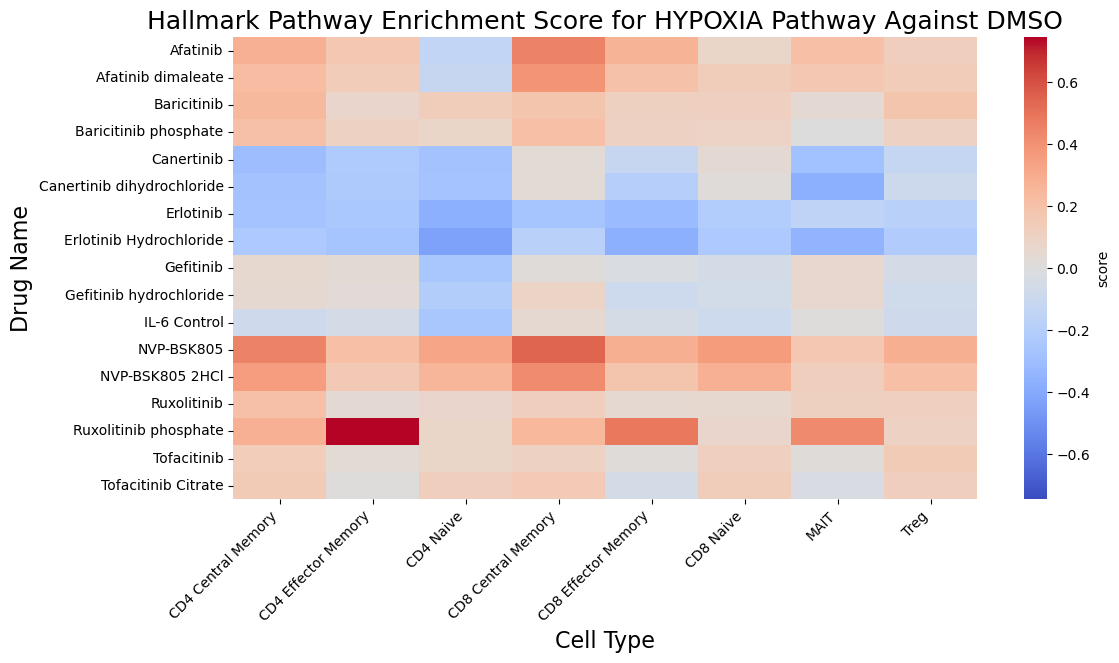

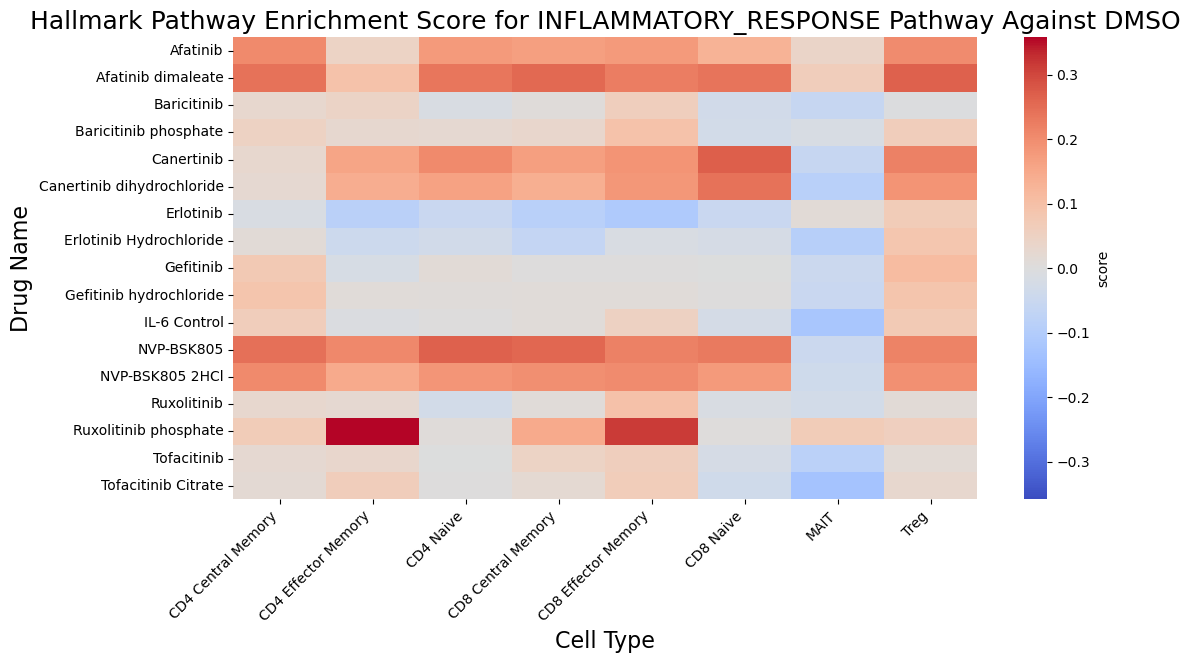

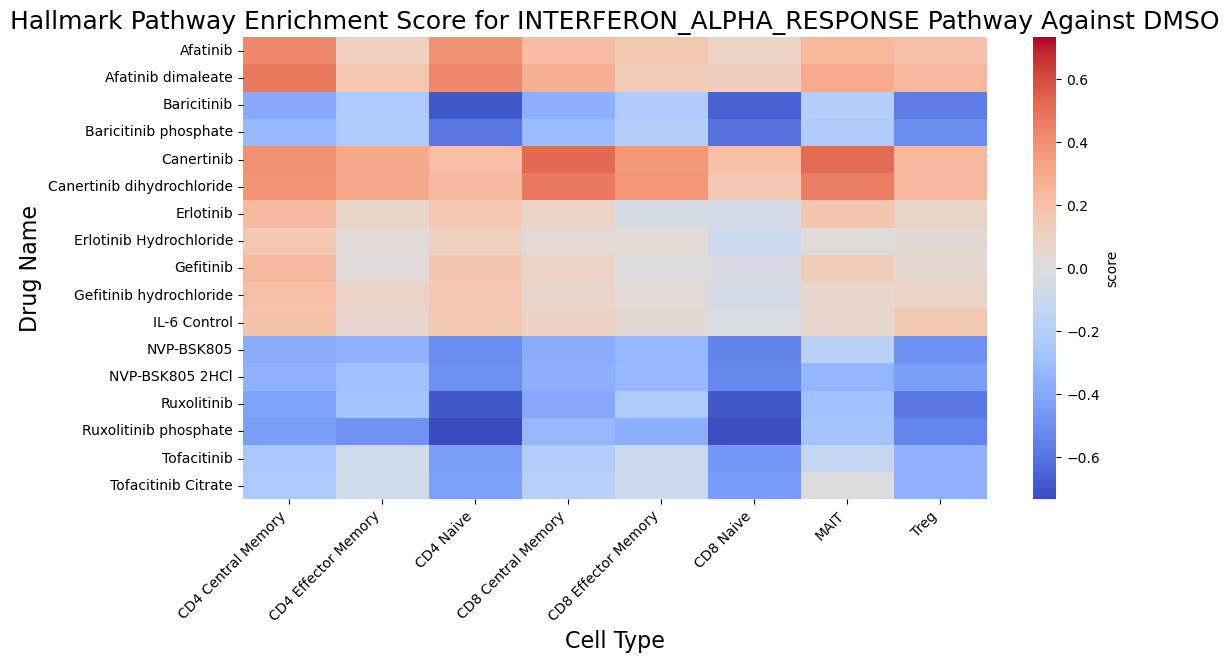

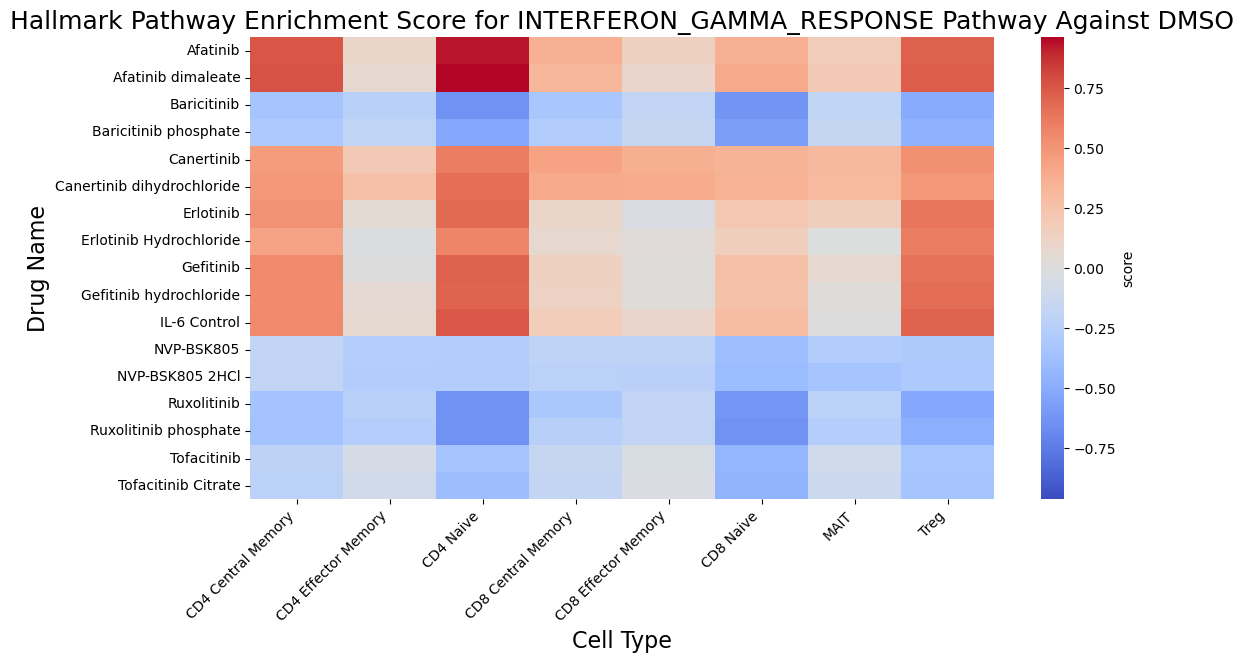

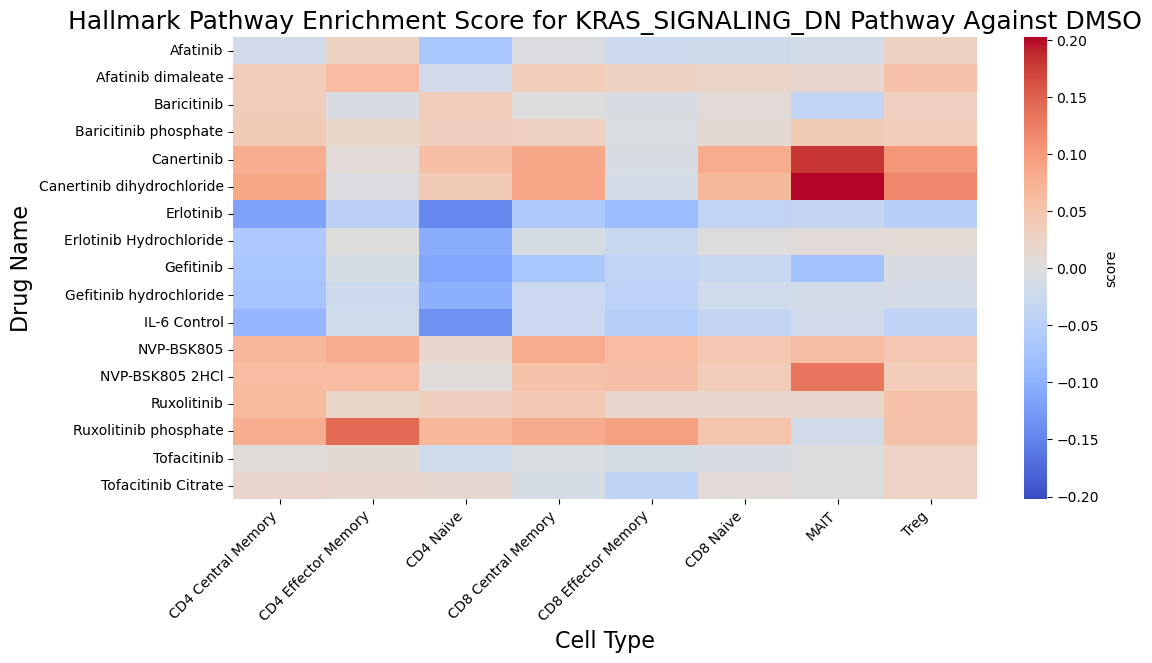

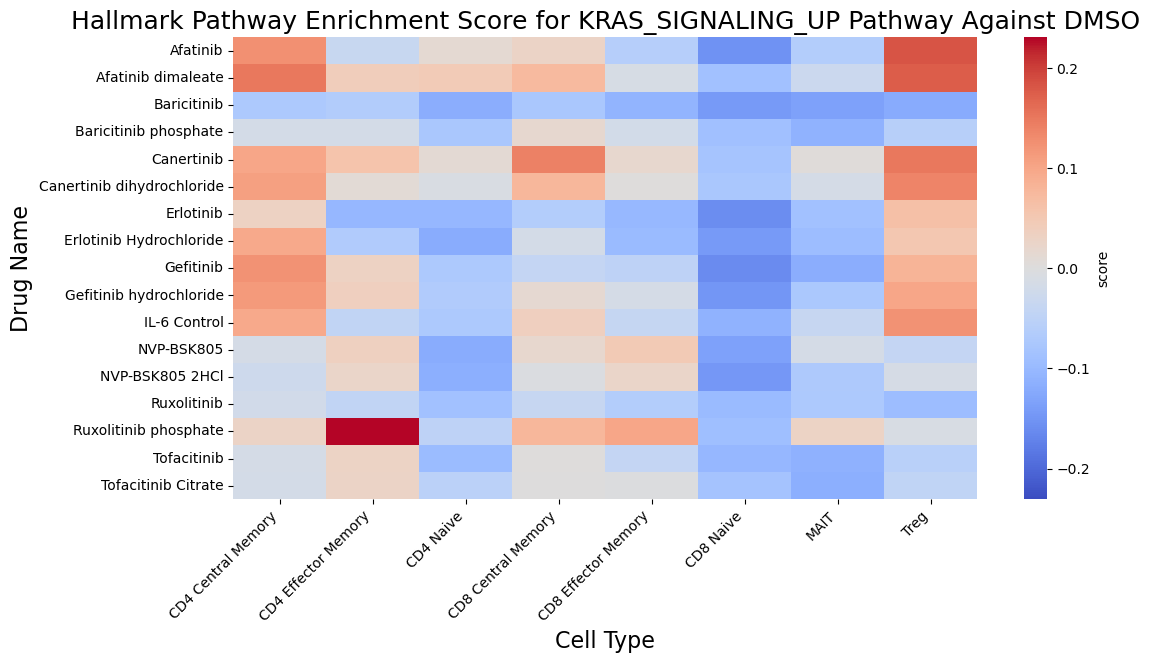

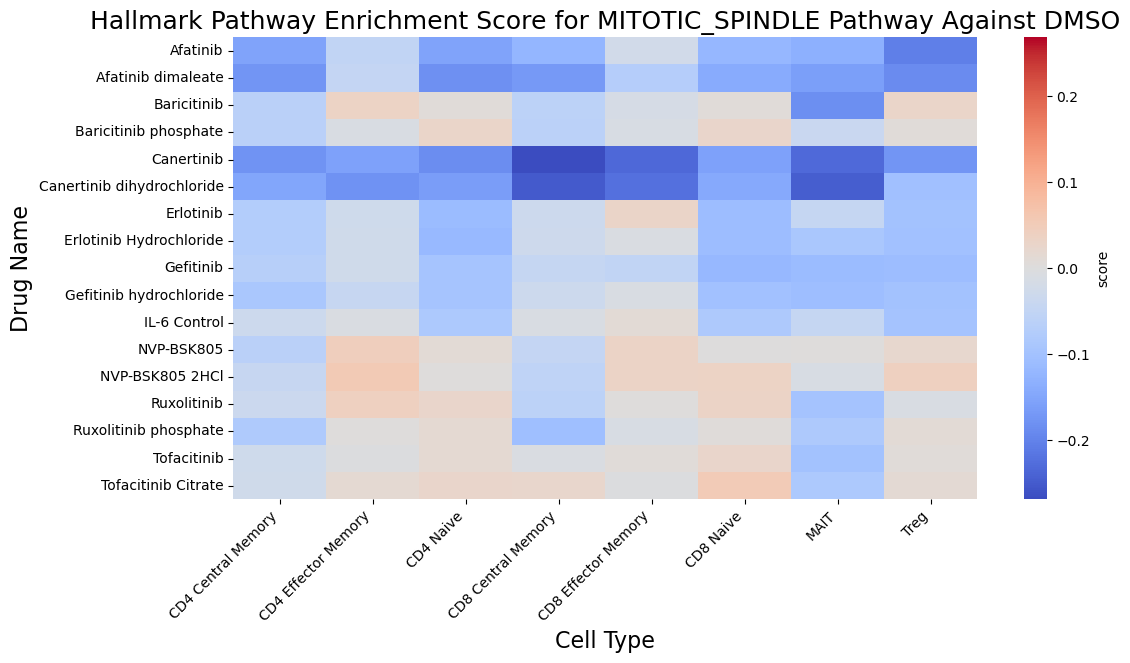

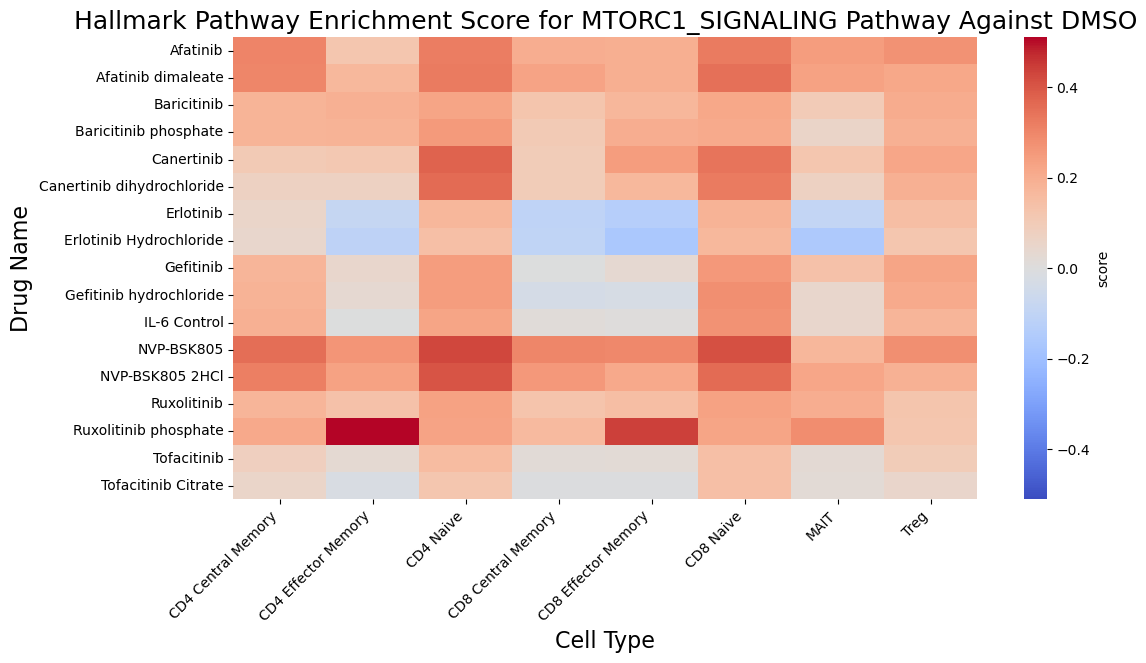

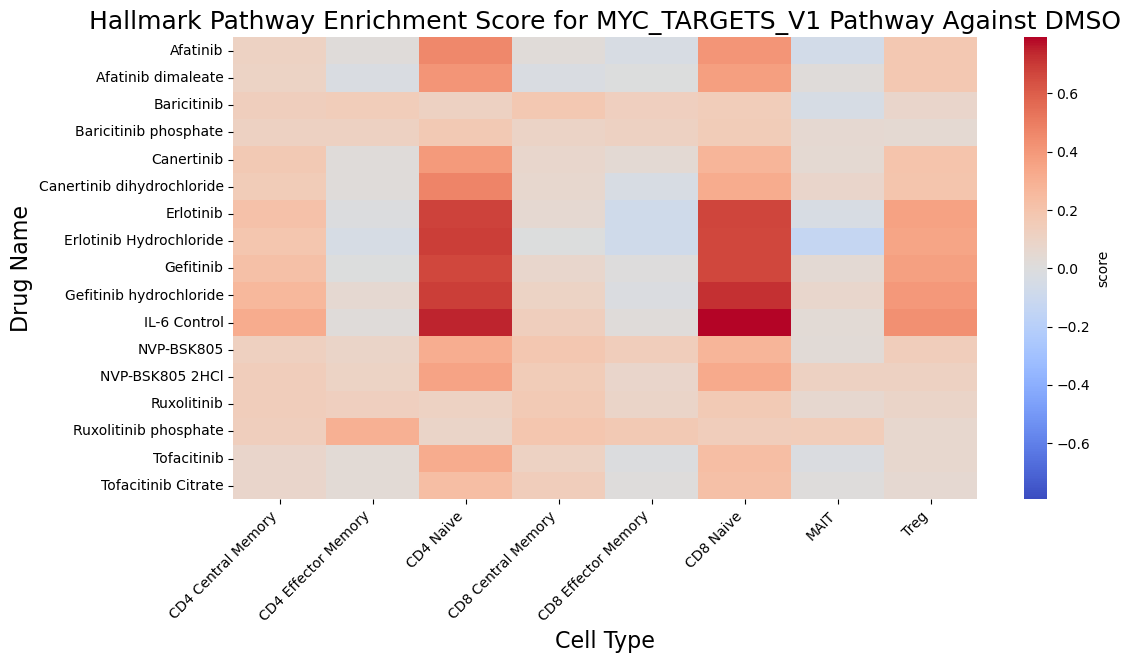

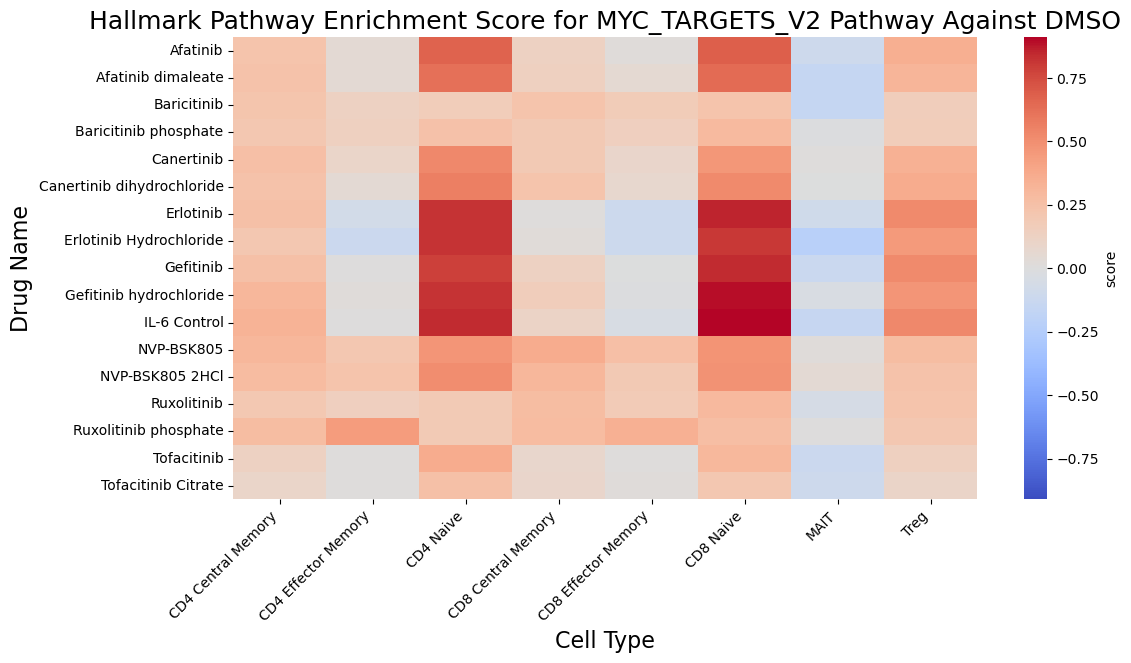

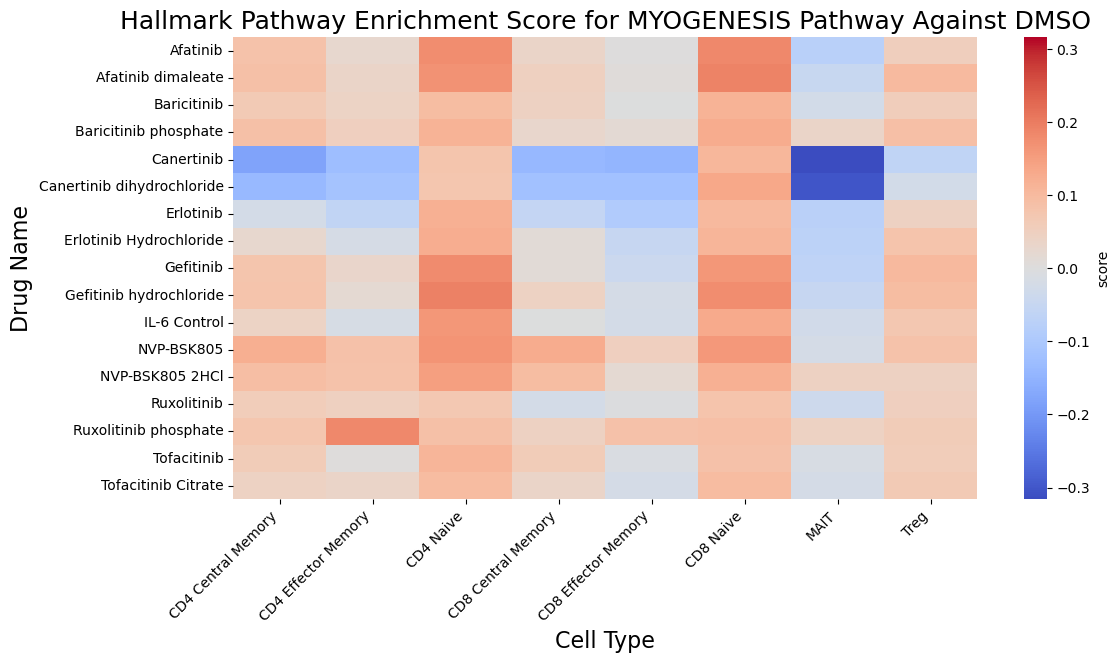

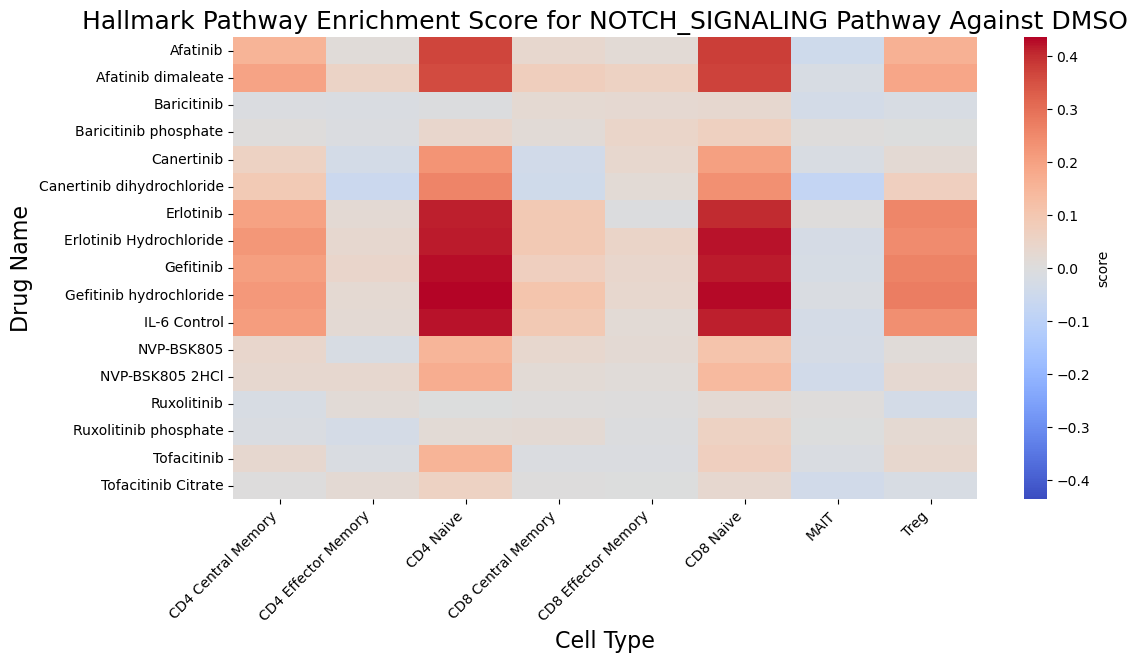

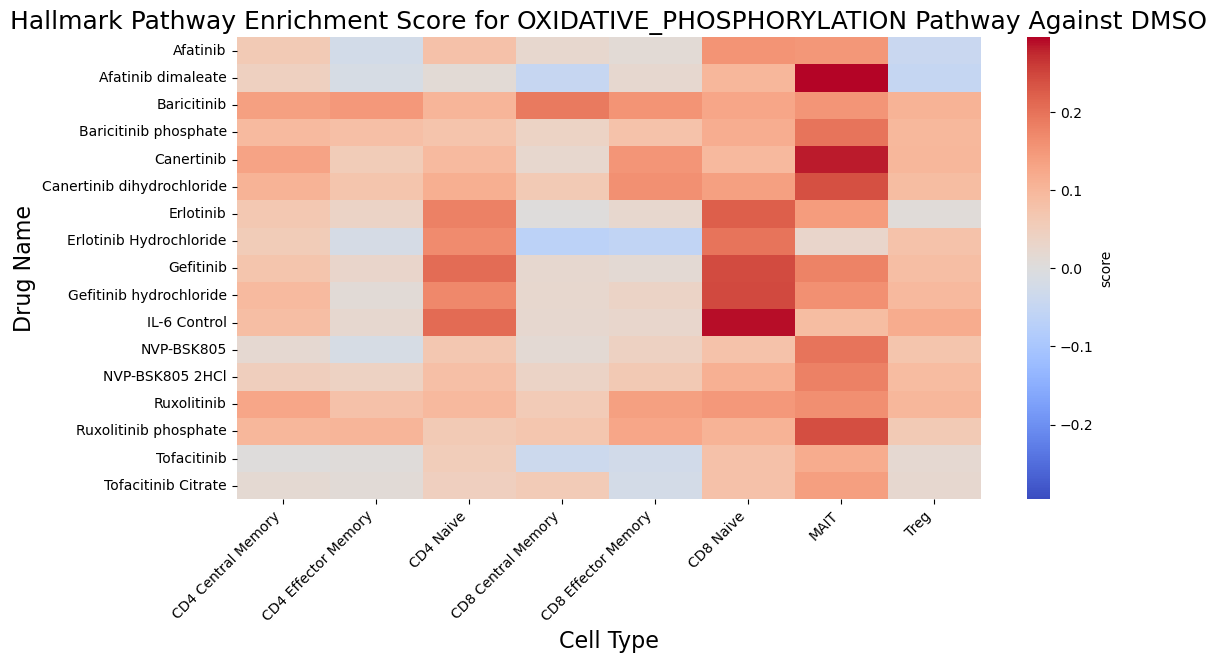

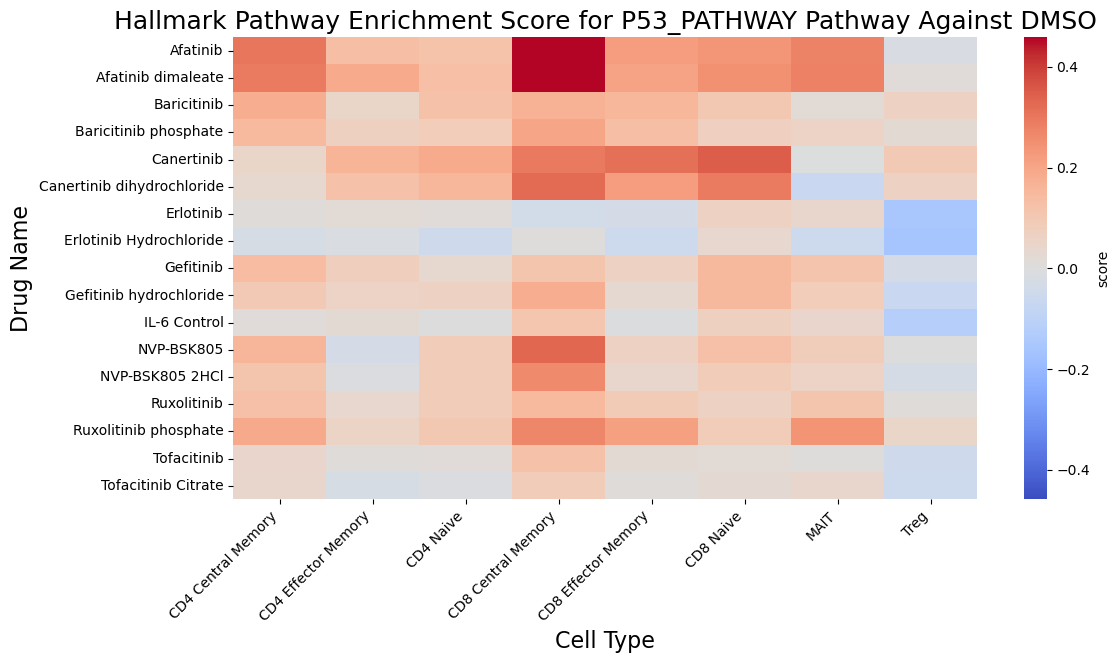

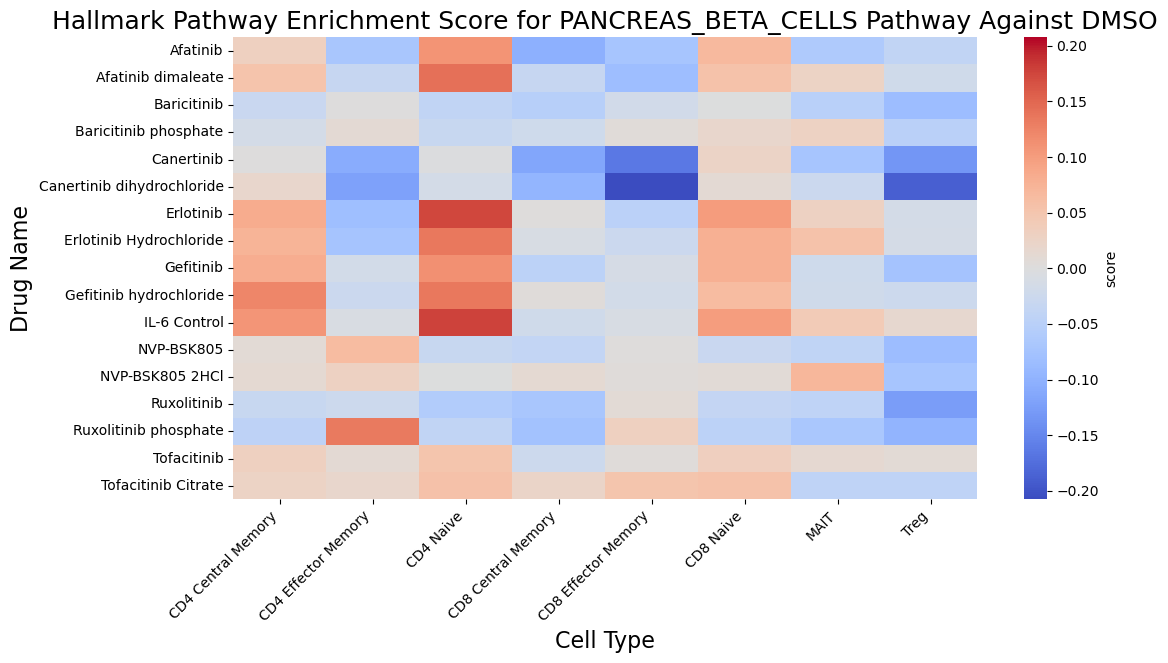

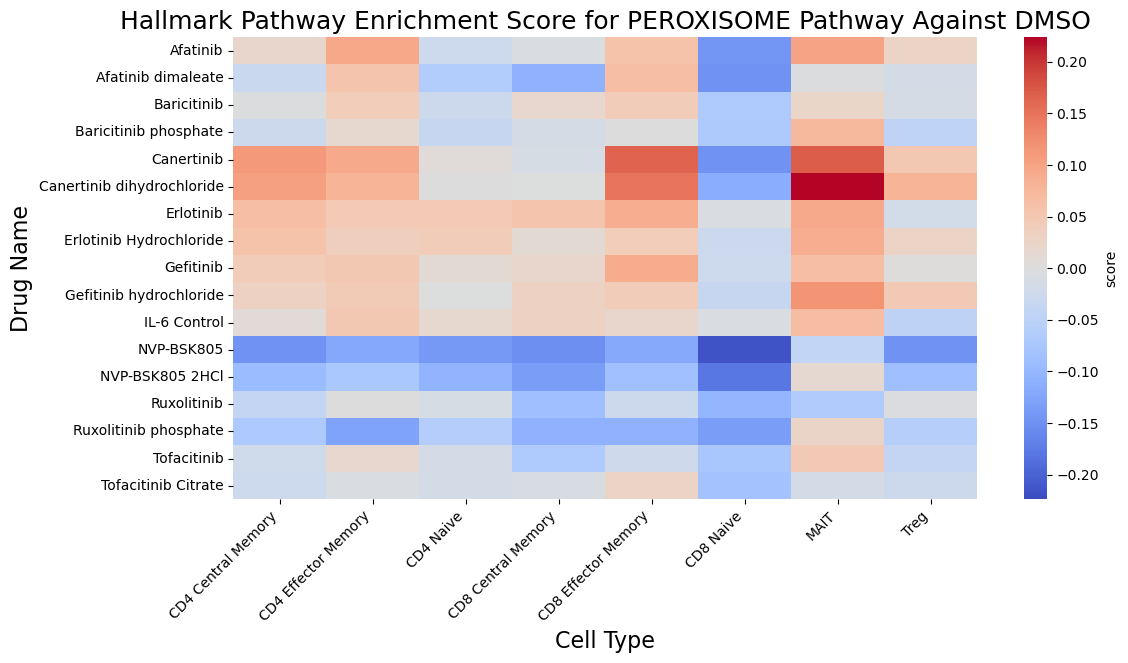

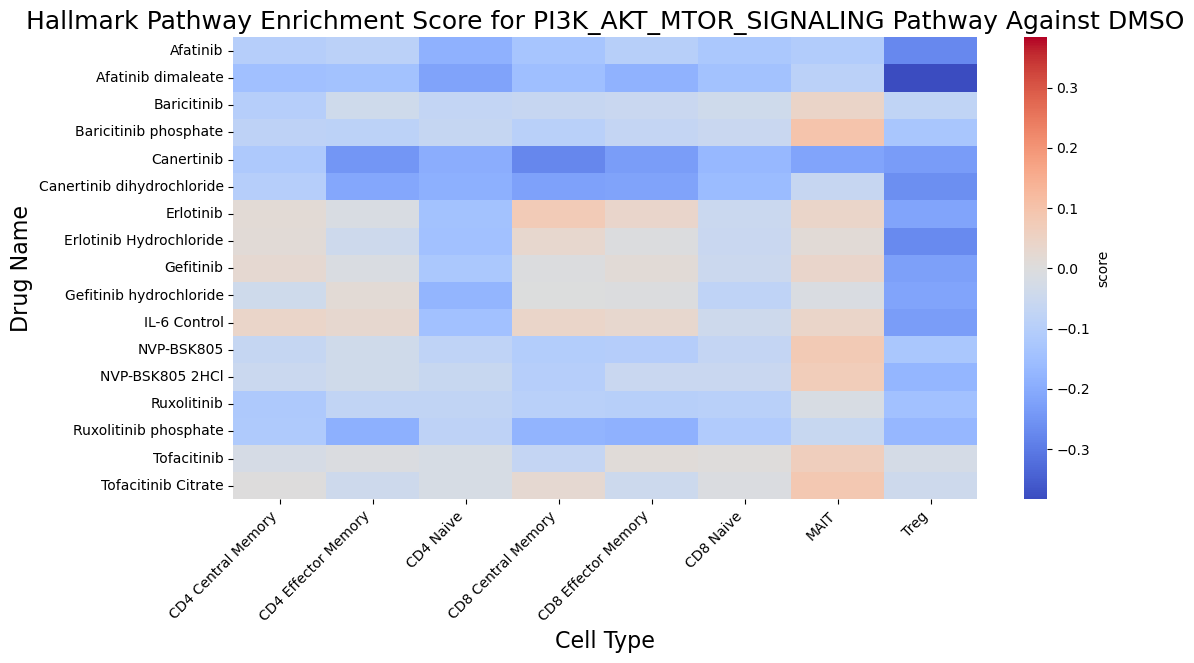

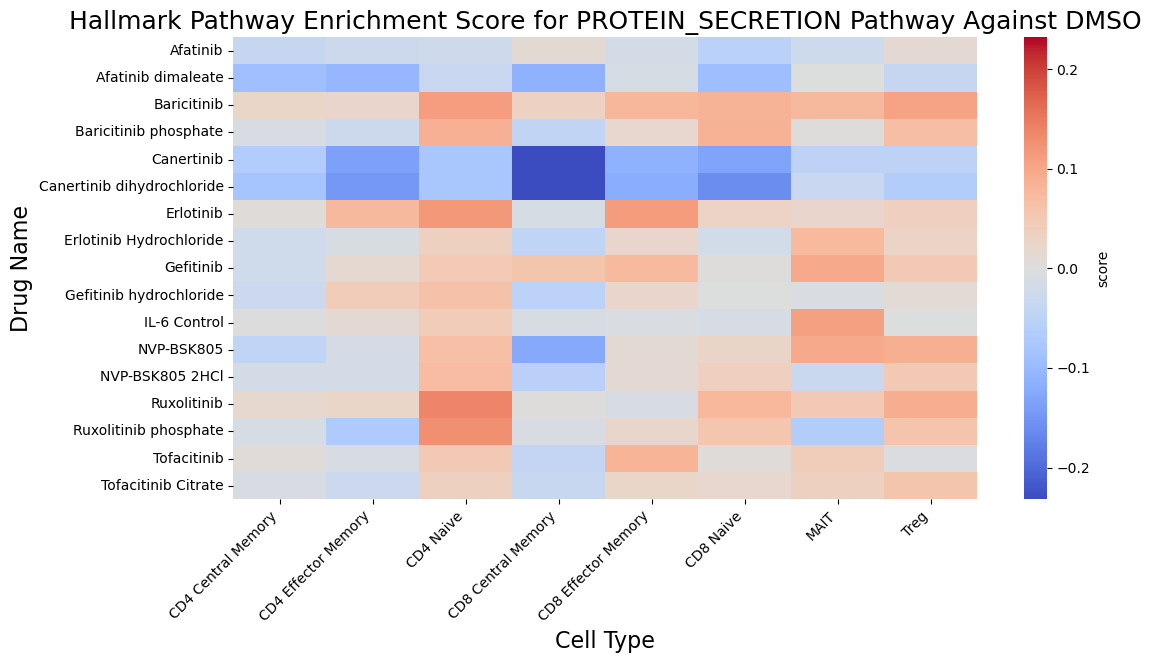

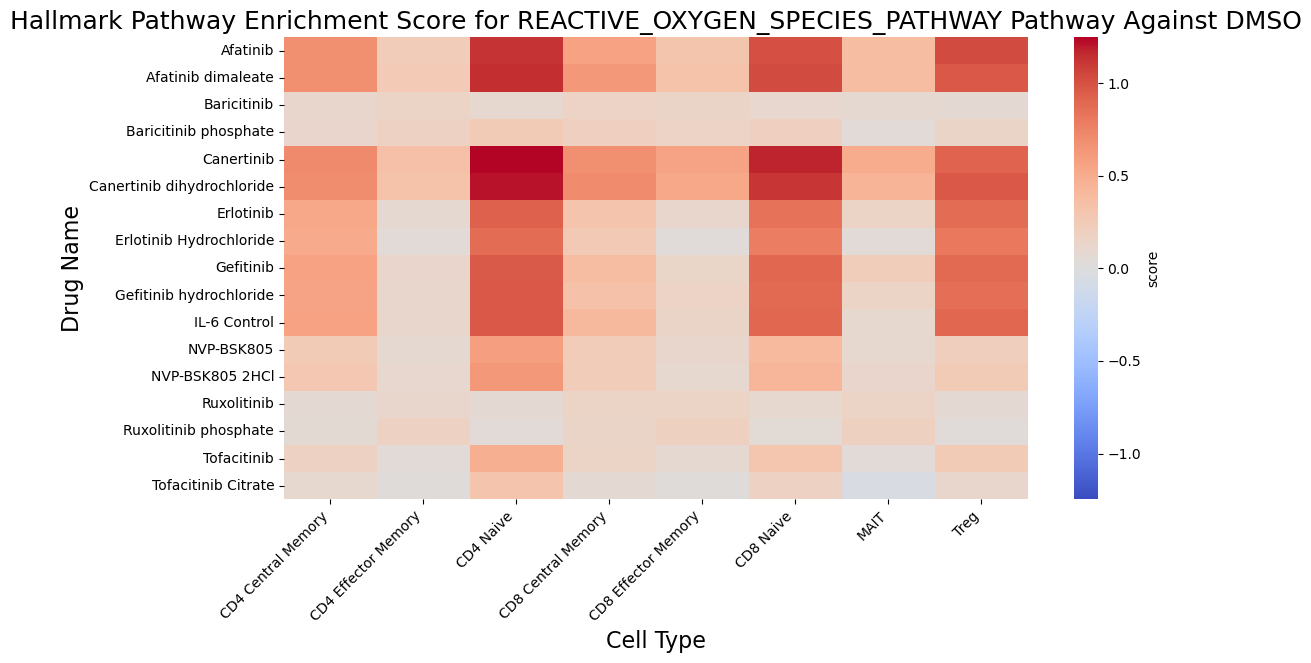

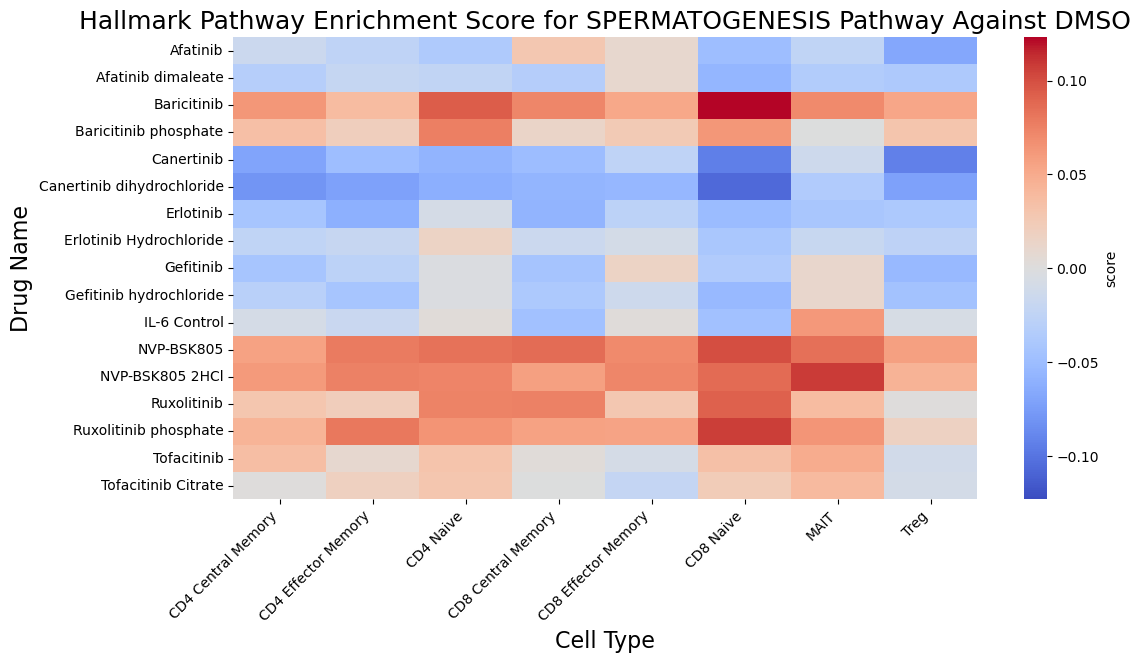

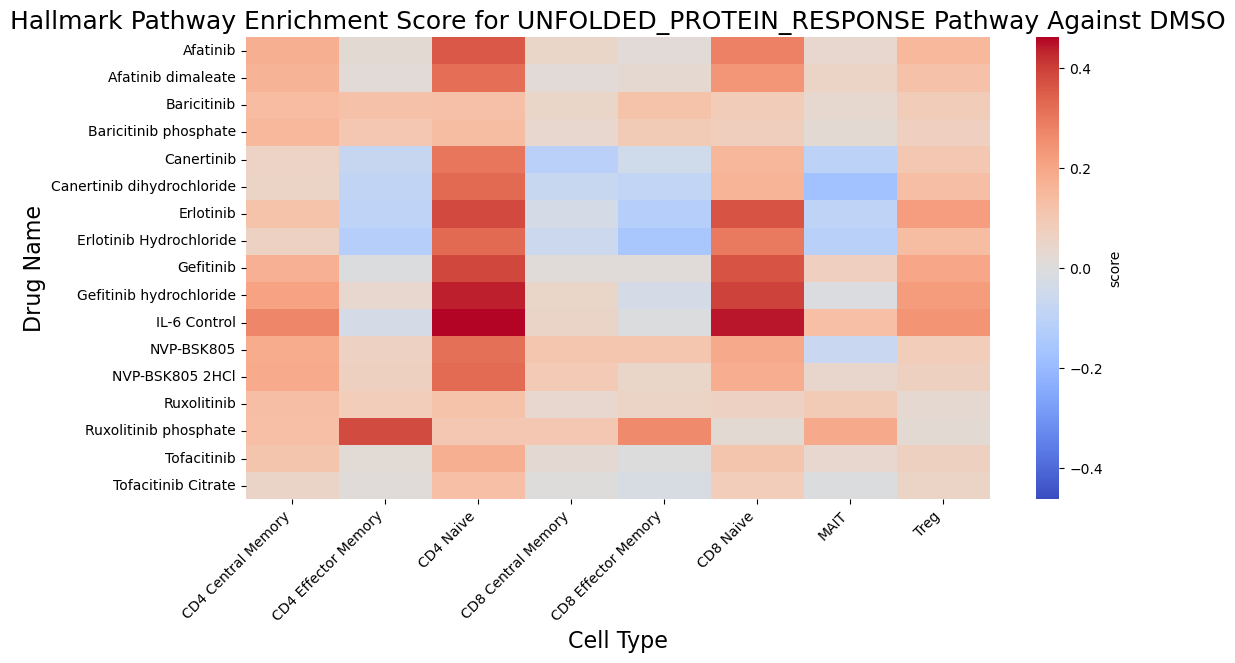

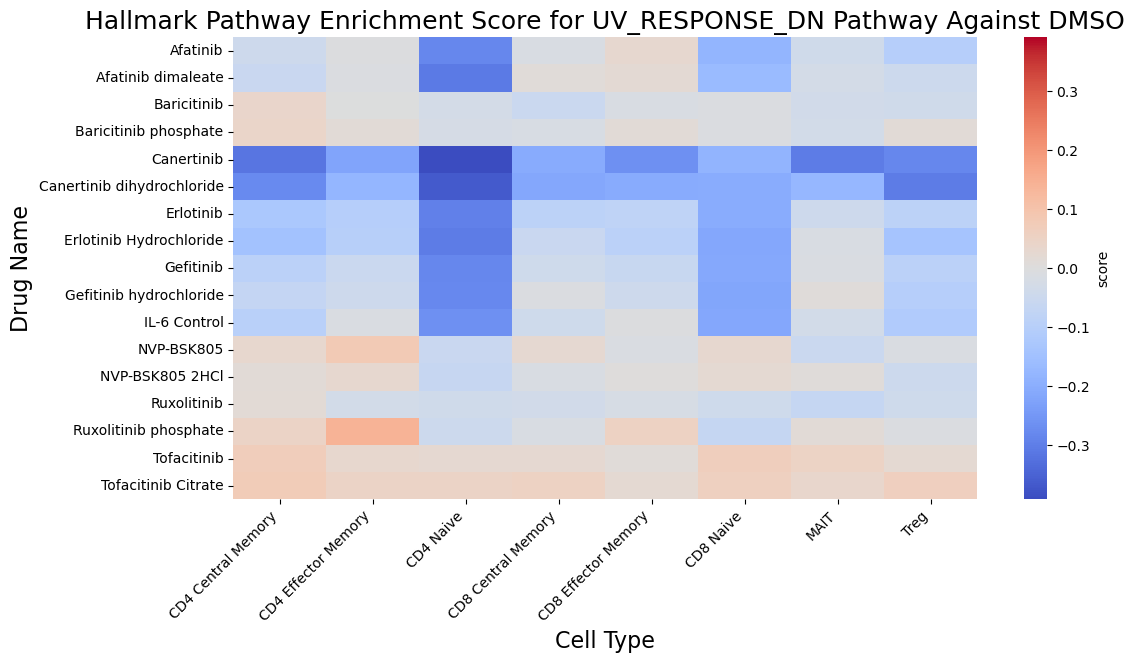

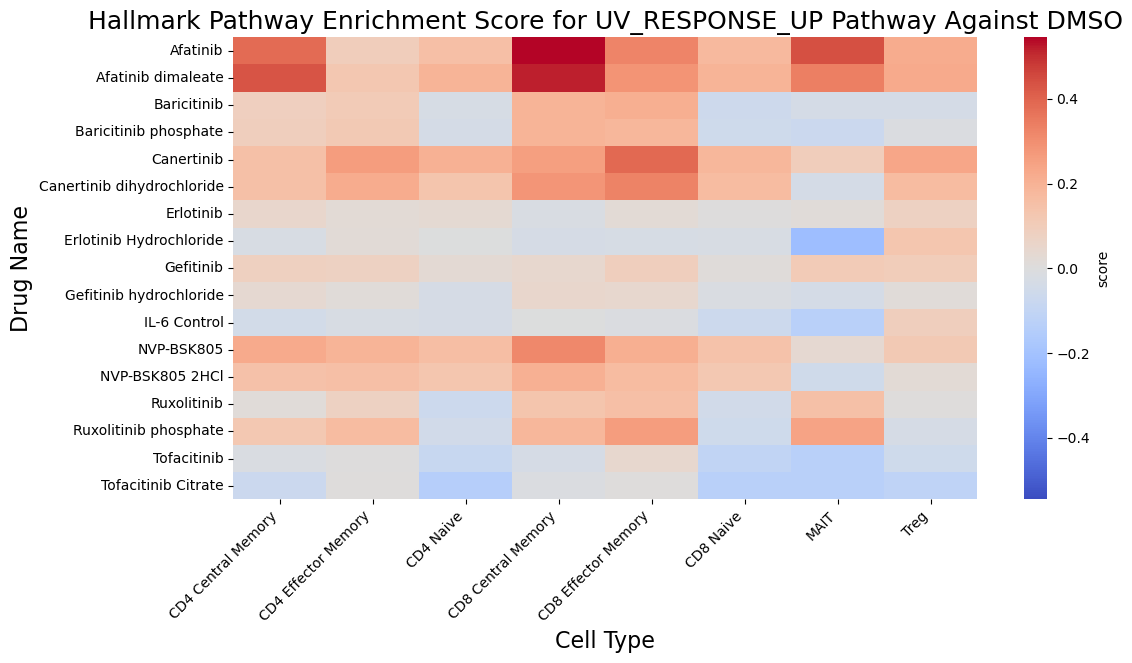

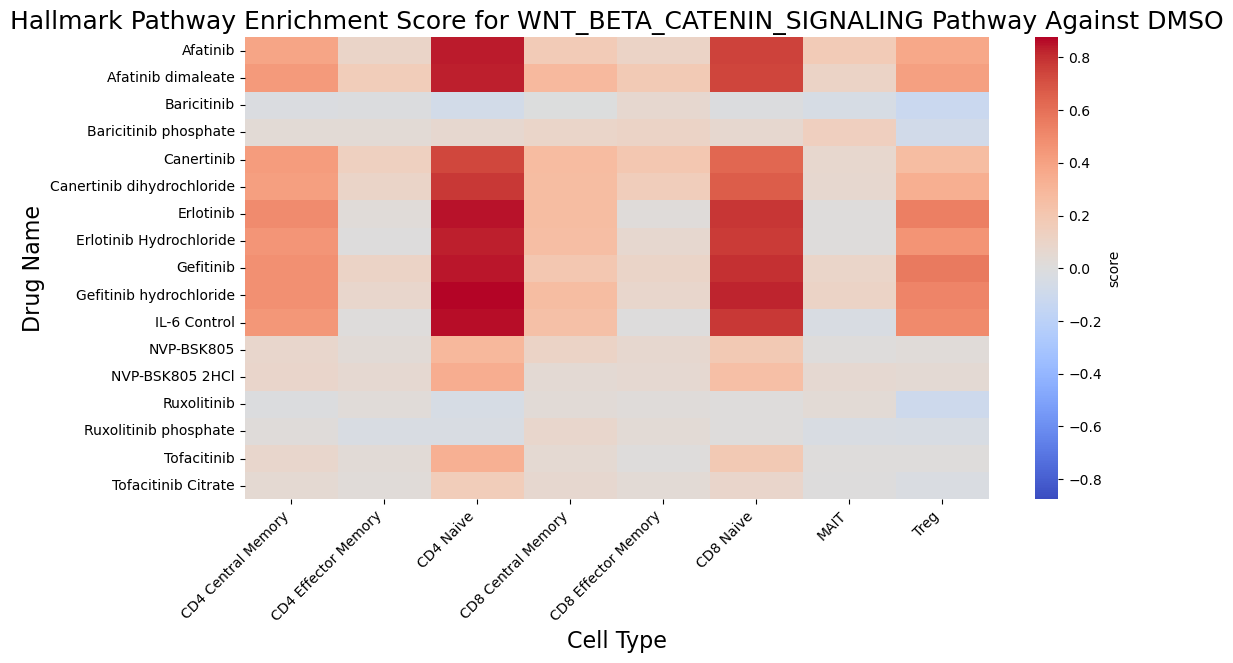

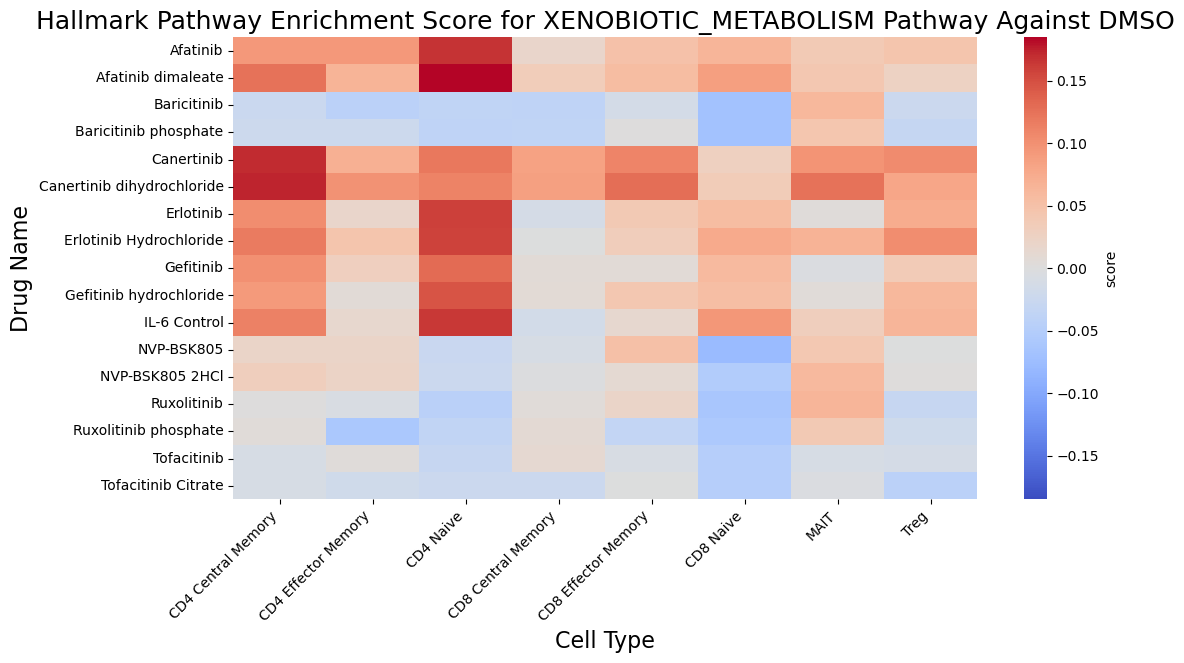

In [32]:
#Heat map: Create heat maps for each pathway (split by pathway) (one axis is cell type, one is drug name) 
#Focusing on JAK/STAT for example → good interpretation to look at just the JAK/STAT pathway to see how each drug changes for each cell type

for pathway in hallmark_pathways:
    
    #getting only the rows with the pathway
    pathway_hallmark_dataframe = all_results_hallmark[all_results_hallmark["name"] == pathway]

    #making the dataframe sutible for sns heatmap
    heatmap_df = pathway_hallmark_dataframe.pivot_table(
        #the rows will be the drug type/treatment/name
        index="group",
        #the columns will be the cell type
        columns="cell_type",
        #the scores will be the pathway scores
        values="meanchange", 
        #this is to get rid of the warning
        observed=False)
    
    #this makes the scale of the bar symmetric (doesn't change the values) !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    vmax = np.nanmax(np.abs(heatmap_df.values))
    
    #plotting the heatmap
    plt.figure(figsize = (12, 6))
    sns.heatmap(data = heatmap_df, 
                #using coolwarm color
                cmap = "coolwarm",
                #centering it at 0, so 0 is white. eveyrthing above is red, everything below is blue
                center=0,
                vmin=-vmax, #making the min value (-) max value !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                vmax=vmax, #making max value the max value!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                #scale lable
                cbar_kws={"label": "score"})
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Hallmark Pathway Enrichment Score for {pathway} Pathway Against DMSO", fontsize=18)
    plt.xlabel("Cell Type", fontsize=16)
    plt.ylabel("Drug Name", fontsize=16)
    plt.show()

### Violin Plots

In [33]:
adata

AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'
    varm: 'PCs'
    layers: 'counts', 'log_transformed'
    obsp: 'distances', 'connectivities'

In [34]:
# making a dictionary of subsetted data where the key is the cell type and the value is the anndata object
subsets_cells = {}

for cell_type in adata.obs['AIFI_L2'].unique():
    # print(f'current cell type is {cell_type}')
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()
    #running the rank gene groups
    sc.tl.rank_genes_groups(
        adata = cell_type_subset,
        groupby = "clean_drug_name",
        reference = "DMSO Control",
        method = "wilcoxon",
        layer = "log_transformed"
    )
    subsets_cells[cell_type] = cell_type_subset
subsets_cells

{'CD4 Central Memory': AnnData object with n_obs × n_vars = 107272 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
     uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon', 'rank_genes_groups'
     obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'
     varm: 'PCs'
     layers: 'counts', 'log_transformed'
     obsp: 'distances', 'connectivities',
 'CD8 Naive': AnnData object with n_obs × n_vars = 78553 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', '

In [35]:
#making dictionary to hold cell type and their scores (key is cell type, value is score andata object)
subset_cell_hallmark_scores = {}

for cell_type, subset_cell in subsets_cells.items():    
    print(f"THE CELL TYPE IS: {cell_type}")
    print(subset_cell)
    #computing pathway scores for each celll
    dc.mt.ulm(data=subset_cell, net=hallmark)
    
    print("THE SCORE ANNDATA IS:")
    #extracting the scores
    score = dc.pp.get_obsm(adata=subset_cell, key="score_ulm")
    print(score)
    
    print(" ")

    #adding the info to the dictionary
    subset_cell_hallmark_scores[cell_type] = score

THE CELL TYPE IS: CD4 Central Memory
AnnData object with n_obs × n_vars = 107272 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample', 'clean_drug_name'
    uns: 'log1p', 'clean_drug_name_colors', 'pca', 'neighbors', 'umap', 'wilcoxon', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'
    varm: 'PCs'
    layers: 'counts', 'log_transformed'
    obsp: 'distances', 'connectivities'
THE SCORE ANNDATA IS:
AnnData object with n_obs × n_vars = 107272 × 50
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'dr

CD4 Central Memory


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


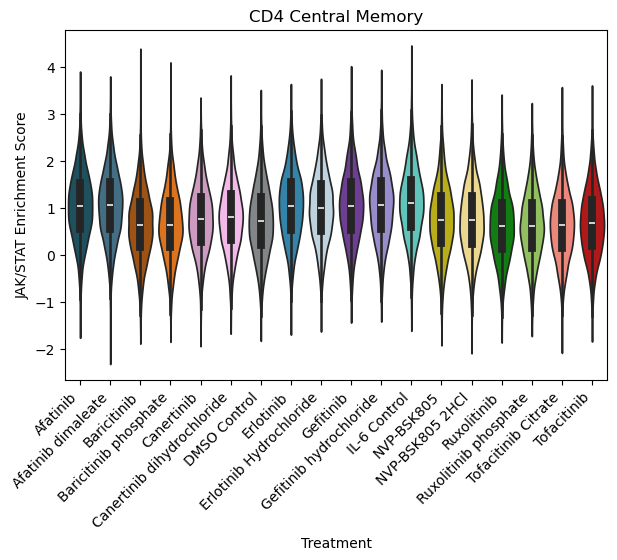

CD8 Naive


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


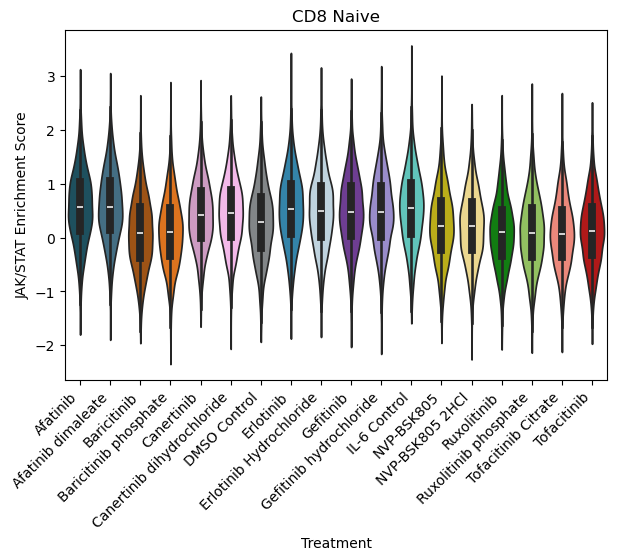

CD8 Effector Memory


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


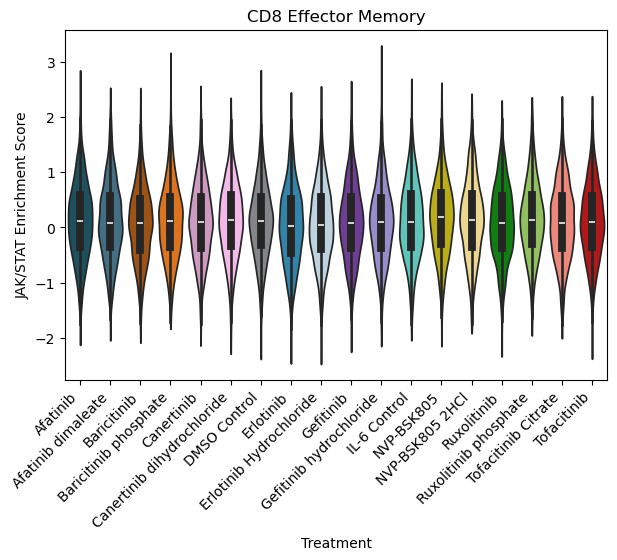

CD8 Central Memory


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


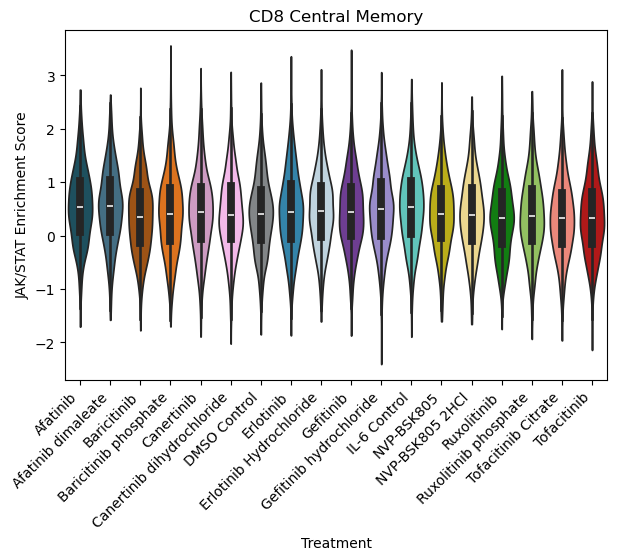

CD4 Naive


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


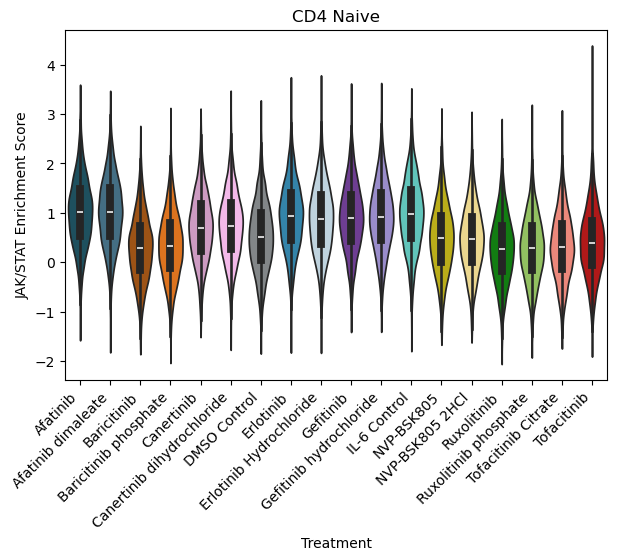

CD4 Effector Memory


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


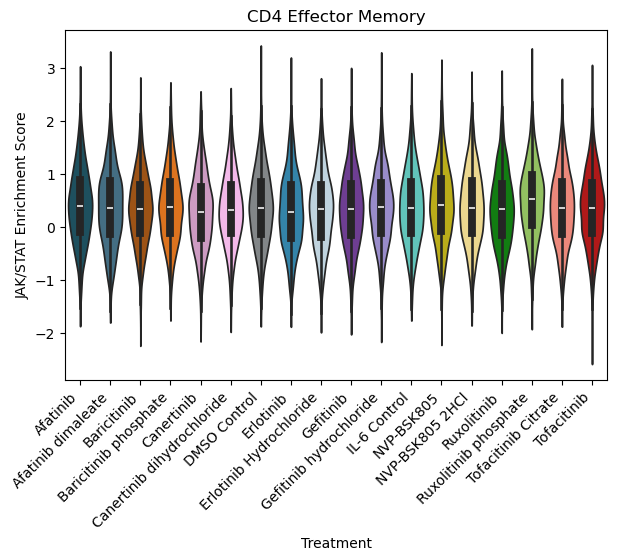

MAIT


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


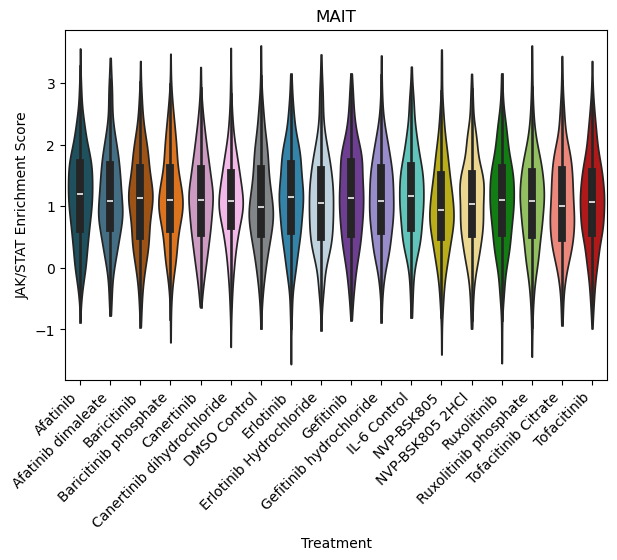

Treg


/tmp/ipykernel_6792/550213066.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6792/550213066.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


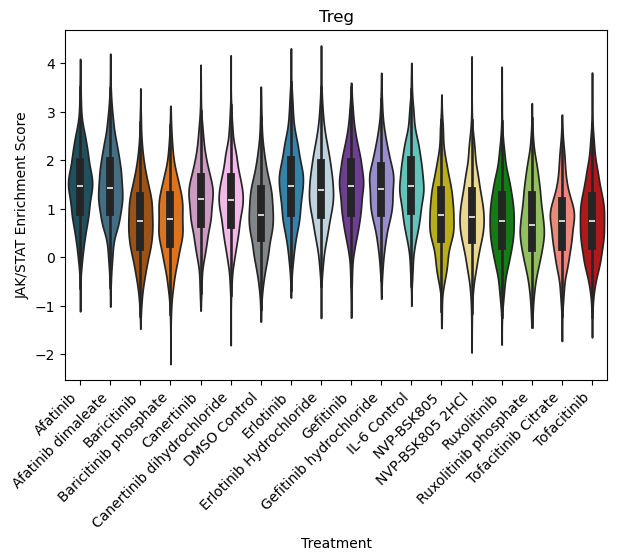

In [36]:
#looping through the cell type and scored adata object
for cell_type, subset_cell_score in subset_cell_hallmark_scores.items():    
    print(cell_type)

    #create the violin plot
    ax = sc.pl.violin(
        subset_cell_score,
        stripplot=False,
        inner="box",
        keys=["IL6_JAK_STAT3_SIGNALING"],  # also 'IL2_STAT5_SIGNALING' is in hallmark
        groupby="clean_drug_name",
        show=False
    )

    #rotating the x axis lables
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Set axis labels
    ax.set_xlabel("Treatment")
    ax.set_ylabel("JAK/STAT Enrichment Score")

    #title is the cell type
    ax.set_title(cell_type)


    #limmiting the white space
    plt.tight_layout()
    
    #showing the figure
    plt.show()

    #saving the figure!
    ax.figure.savefig(
        f"hallmark_{cell_type}_violin_plot.svg",
        dpi=300,
        bbox_inches="tight"
        )


# Converting df to .csv

In [ ]:
#progeny df to csv
all_results_progeny.to_csv('ssGSEA_progeny.csv')

In [ ]:
#hallmark df to csv
all_results_hallmark.to_csv('ssGSEA_hallmark.csv')

# Uploading Data to HISE

In [ ]:
uuid_list = [
    '02765813-6130-4fac-8708-f01768aa05b6',
    '06b73fab-62d2-4fc3-8a86-2df960cbc1ea',
    '1aecccab-f62a-4c49-b2fe-ba5777930262',
    '207c5f6c-92ec-4690-a7fd-07b0cbebd9f6',
    '3adc31cf-1ea9-4a7d-bc63-31358cb8a325',
    '45e4bd43-4fae-49df-8974-8d043e395f73',
    '4c13d814-1493-48f8-8021-a819b556e97b',
    '56bc5070-2968-4c6b-8198-4e997c75e4fe',
    '64e7735c-e89b-41ef-a293-a39b9ed5ade9',
    '72755c82-880d-4814-8322-6a81ed07466d',
    '9693f71c-dcb3-4d40-b2ad-74fc2ad147de',
    '9f37360e-0191-418b-ab51-fdb86ab9be09',
    'a3bc4704-5fe3-4a74-bce5-0700689db1f6',
    'af42c180-0218-4918-ae12-0a4f43c4aa1f',
    'b790716c-b2de-4028-ad60-1e5a7b81f05d',
    'bfa4c2f1-69d5-4bcf-a1a6-9beb69dbffc9',
    'd076758f-3d76-49b7-91be-0217eefcdf26',
    'd2f8da49-85eb-4dea-a166-5308bb73de91'
]

file_list = hisepy.cache_files(uuid_list)

In [ ]:
#a function to make unique destination strings using the periodic table elements
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
        
    rand_str = '-'.join(rand_el)
    return rand_str


In [ ]:
#getting unique title for upload, using UTC time
from datetime import datetime, timezone

#getting the current time and saving it
utc_current = datetime.now(timezone.utc)
print(utc_current)

#lisiting the files to upload
files_to_upload = [
    "ssGSEA_progeny.csv",
    "ssGSEA_hallmark.csv"
]

#uploading the files
hisepy.upload_files(
    files = files_to_upload,
    study_space_id = "c8a94b84-b0b7-40a9-980b-81a63ad6e115",
    title = f"ssGSEA_data_h5ad_{utc_current}",
    input_file_ids = uuid_list,
    #destination is randomly generated elements
    destination = element_id()
)

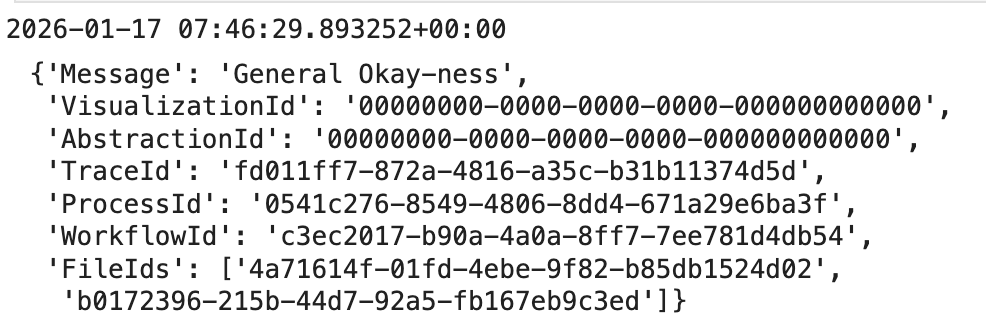
